# Dans quelle mesure les variables météorologiques permettent-elles d’anticiper la catégorie globale de qualité de l’air, indépendamment des mesures directes de polluants ?

## Exploration

### 1. Imports

*Cette section est dédiée à l'importation de l'ensemble des bibliothèques et outils nécessaires à la bonne exécution de notre script et à la manipulation des données.*

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import xgboost as xgb
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import joblib


### 2. Chargement des données

*Cette section permet d'importer les données brutes qui serviront de base à notre étude et à l'entraînement futur de notre modèle de prédiction.*

In [3]:
df = pd.read_csv("../Dataset/GlobalWeatherRepository.csv")

df.head()

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15,26.6,79.8,Partly Cloudy,...,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45,19.0,66.2,Partly cloudy,...,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45,23.0,73.4,Sunny,...,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45,6.3,43.3,Light drizzle,...,0.7,0.9,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45,26.0,78.8,Partly cloudy,...,183.4,262.3,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55


### 3. Exploration

*Cette étape permet d'obtenir un premier aperçu technique de la structure des données brutes afin d'en évaluer le potentiel. L'objectif est d'identifier précisément les variables à notre disposition, de détecter la présence de valeurs manquantes et de vérifier la cohérence des types de données pour déterminer les transformations nécessaires avant le nettoyage.*

In [63]:
df.shape

(126476, 41)

In [64]:
df.columns

Index(['country', 'location_name', 'latitude', 'longitude', 'timezone',
       'last_updated_epoch', 'last_updated', 'temperature_celsius',
       'temperature_fahrenheit', 'condition_text', 'wind_mph', 'wind_kph',
       'wind_degree', 'wind_direction', 'pressure_mb', 'pressure_in',
       'precip_mm', 'precip_in', 'humidity', 'cloud', 'feels_like_celsius',
       'feels_like_fahrenheit', 'visibility_km', 'visibility_miles',
       'uv_index', 'gust_mph', 'gust_kph', 'air_quality_Carbon_Monoxide',
       'air_quality_Ozone', 'air_quality_Nitrogen_dioxide',
       'air_quality_Sulphur_dioxide', 'air_quality_PM2.5', 'air_quality_PM10',
       'air_quality_us-epa-index', 'air_quality_gb-defra-index', 'sunrise',
       'sunset', 'moonrise', 'moonset', 'moon_phase', 'moon_illumination'],
      dtype='object')

In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126476 entries, 0 to 126475
Data columns (total 41 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   country                       126476 non-null  object 
 1   location_name                 126476 non-null  object 
 2   latitude                      126476 non-null  float64
 3   longitude                     126476 non-null  float64
 4   timezone                      126476 non-null  object 
 5   last_updated_epoch            126476 non-null  int64  
 6   last_updated                  126476 non-null  object 
 7   temperature_celsius           126476 non-null  float64
 8   temperature_fahrenheit        126476 non-null  float64
 9   condition_text                126476 non-null  object 
 10  wind_mph                      126476 non-null  float64
 11  wind_kph                      126476 non-null  float64
 12  wind_degree                   126476 non-nul

In [66]:
df.isna().sum().sort_values(ascending=False)

country                         0
location_name                   0
latitude                        0
longitude                       0
timezone                        0
last_updated_epoch              0
last_updated                    0
temperature_celsius             0
temperature_fahrenheit          0
condition_text                  0
wind_mph                        0
wind_kph                        0
wind_degree                     0
wind_direction                  0
pressure_mb                     0
pressure_in                     0
precip_mm                       0
precip_in                       0
humidity                        0
cloud                           0
feels_like_celsius              0
feels_like_fahrenheit           0
visibility_km                   0
visibility_miles                0
uv_index                        0
gust_mph                        0
gust_kph                        0
air_quality_Carbon_Monoxide     0
air_quality_Ozone               0
air_quality_Ni

Nous n'avons aucune valeurs nulles dans ce Dataset !

In [4]:
# Créer une table de correspondance entre chaque nom de colonne et son libellé descriptif

labels = {
    "country": "Country of the weather data",
    "location_name": "Name of the location (city)",
    "latitude": "Latitude coordinate of the location",
    "longitude": "Longitude coordinate of the location",
    "timezone": "Timezone of the location",
    "last_updated_epoch": "Unix timestamp of the last data update",
    "last_updated": "Local time of the last data update",
    "temperature_celsius": "Temperature in degrees Celsius",
    "temperature_fahrenheit": "Temperature in degrees Fahrenheit",
    "condition_text": "Weather condition description",
    "wind_mph": "Wind speed in miles per hour",
    "wind_kph": "Wind speed in kilometers per hour",
    "wind_degree": "Wind direction in degrees",
    "wind_direction": "Wind direction as a 16-point compass",
    "pressure_mb": "Pressure in millibars",
    "pressure_in": "Pressure in inches",
    "precip_mm": "Precipitation amount in millimeters",
    "precip_in": "Precipitation amount in inches",
    "humidity": "Humidity as a percentage",
    "cloud": "Cloud cover as a percentage",
    "feels_like_celsius": "Feels-like temperature in Celsius",
    "feels_like_fahrenheit": "Feels-like temperature in Fahrenheit",
    "visibility_km": "Visibility in kilometers",
    "visibility_miles": "Visibility in miles",
    "uv_index": "UV Index",
    "gust_mph": "Wind gust in miles per hour",
    "gust_kph": "Wind gust in kilometers per hour",
    "air_quality_Carbon_Monoxide": "Air quality measurement: Carbon Monoxide",
    "air_quality_Ozone": "Air quality measurement: Ozone",
    "air_quality_Nitrogen_dioxide": "Air quality measurement: Nitrogen Dioxide",
    "air_quality_Sulphur_dioxide": "Air quality measurement: Sulphur Dioxide",
    "air_quality_PM2.5": "Air quality measurement: PM2.5",
    "air_quality_PM10": "Air quality measurement: PM10",
    "air_quality_us-epa-index": "Air quality measurement: US EPA Index",
    "air_quality_gb-defra-index": "Air quality measurement: GB DEFRA Index",
    "sunrise": "Local time of sunrise",
    "sunset": "Local time of sunset",
    "moonrise": "Local time of moonrise",
    "moonset": "Local time of moonset",
    "moon_phase": "Current moon phase",
    "moon_illumination": "Moon illumination percentage"
}

label_df = pd.DataFrame(list(labels.items()), columns=["column", "label"])
label_df['unique_values'] = label_df['column'].apply(lambda col: df[col].nunique())
label_df['apercu_valeurs_uniques'] = label_df['column'].apply(lambda col: list(df[col].unique()[:5]))
label_df

,column,label,unique_values,apercu_valeurs_uniques
0,country,Country of the weather data,211,"[Afghanistan, Albania, Algeria, Andorra, Angola]"
1,location_name,Name of the location (city),257,"[Kabul, Tirana, Algiers, Andorra La Vella, Lua..."
2,latitude,Latitude coordinate of the location,397,"[34.52, 41.33, 36.76, 42.5, -8.84]"
3,longitude,Longitude coordinate of the location,402,"[69.18, 19.82, 3.05, 1.52, 13.23]"
4,timezone,Timezone of the location,199,"[Asia/Kabul, Europe/Tirane, Africa/Algiers, Eu..."
5,last_updated_epoch,Unix timestamp of the last data update,1195,"[1715849100, 1715868000, 1715868900, 171596160..."
6,last_updated,Local time of the last data update,21266,"[2024-05-16 13:15, 2024-05-16 10:45, 2024-05-1..."
7,temperature_celsius,Temperature in degrees Celsius,704,"[26.6, 19.0, 23.0, 6.3, 26.0]"
8,temperature_fahrenheit,Temperature in degrees Fahrenheit,1166,"[79.8, 66.2, 73.4, 43.3, 78.8]"
9,condition_text,Weather condition description,49,"[Partly Cloudy, Partly cloudy, Sunny, Light dr..."


4 types de variables : 

- Variables géographiques : 

        - country
        - location_name
        - latitude
        - longitude
        - timezone

- Variables météo : 

        - temperature (C/F)
        - humidity
        - pressure
        - wind
        - precipitation
        - cloud
        - visibility
        - uv_index
        - sunrise/sunset
        - moon_phase
        - ...

- Polluants : 

        - CO
        - Ozone
        - NO2
        - SO2
        - PM2.5
        - PM10
        - US EPA Index
        - GB DEFRA Index

- Dimension temporelle : 

        - last_updated
        - last_updated_epoch

Les deux colonnes suivantes codent un indice qualitatif de pollution atmosphérique :

- **`air_quality_us-epa-index`** : mesure de la qualité de l’air selon l’échelle de l’US EPA (United States Environmental Protection Agency).  Les valeurs vont de 1 à 6, correspondant à des catégories allant de "Good" à "Hazardous".
- **`air_quality_gb-defra-index`** : mesure équivalente selon l’échelle britannique DEFRA.  Les valeurs se situent entre 1 et 10, un numéro plus élevé indiquant une mauvaise qualité de l’air.

Ci-dessous, on construit des tables de référence associant chaque valeur d'indice à son libellé descriptif et à un code couleur normalisé, facilitant ainsi la cohérence visuelle entre les données et les graphiques.

In [5]:
import pandas as pd

# --- CONFIGURATION US EPA ---

us_map = {
    1: 'Good',
    2: 'Moderate',
    3: 'Unhealthy for Sensitive Groups',
    4: 'Unhealthy',
    5: 'Very Unhealthy',
    6: 'Hazardous'
}
us_colors_list = ['#00e400', '#ffff00', '#ff7e00', '#ff0000', '#8f3f97', '#7e0023']


us_categories = sorted(df['air_quality_us-epa-index'].dropna().unique())

us_df = pd.DataFrame({
    'value': [int(v) for v in us_categories],
    'label': [us_map.get(int(v), f'Category {int(v)}') for v in us_categories],
    'color': [us_colors_list[int(v)-1] for v in us_categories]
})

# --- CONFIGURATION GB DEFRA ---

gb_map = {
    **{i: 'Low' for i in range(1, 4)},
    **{i: 'Moderate' for i in range(4, 7)},
    **{i: 'High' for i in range(7, 10)},
    10: 'Very High'
}

defra_colors_list = [
    '#00e400', '#00e400', '#00e400', # 1, 2, 3 (Low)
    '#ffff00', '#ffff00',           # 4, 5 (Moderate)
    '#ff7e00',                       # 6 (Moderate)
    '#ffb3d9',                       # 7 (High)
    '#ff0000',                       # 8 (High)
    '#7e0023',                       # 9 (High)
    '#8f3f97'                        # 10 (Very High)
]


gb_categories = sorted(df['air_quality_gb-defra-index'].dropna().unique())

gb_df = pd.DataFrame({
    'value': [int(v) for v in gb_categories],
    'label': [gb_map.get(int(v), f'Level {int(v)}') for v in gb_categories],
    'color': [defra_colors_list[int(v)-1] for v in gb_categories]
})

In [6]:
# Affichage du tableau US avec couleurs

print("Référence US EPA Index :")
display(us_df.style.apply(lambda x: [f'background-color: {v}; color: black' for v in x], subset=['color']))

# Affichage du tableau GB avec couleurs

print("\nRéférence GB DEFRA Index :")
display(gb_df.style.apply(lambda x: [f'background-color: {v}; color: {"white" if v in ["#7e0023", "#8f3f97"] else "black"}' for v in x], subset=['color']))

Référence US EPA Index :


,value,label,color
0,1,Good,#00e400
1,2,Moderate,#ffff00
2,3,Unhealthy for Sensitive Groups,#ff7e00
3,4,Unhealthy,#ff0000
4,5,Very Unhealthy,#8f3f97
5,6,Hazardous,#7e0023



Référence GB DEFRA Index :


,value,label,color
0,1,Low,#00e400
1,2,Low,#00e400
2,3,Low,#00e400
3,4,Moderate,#ffff00
4,5,Moderate,#ffff00
5,6,Moderate,#ff7e00
6,7,High,#ffb3d9
7,8,High,#ff0000
8,9,High,#7e0023
9,10,Very High,#8f3f97


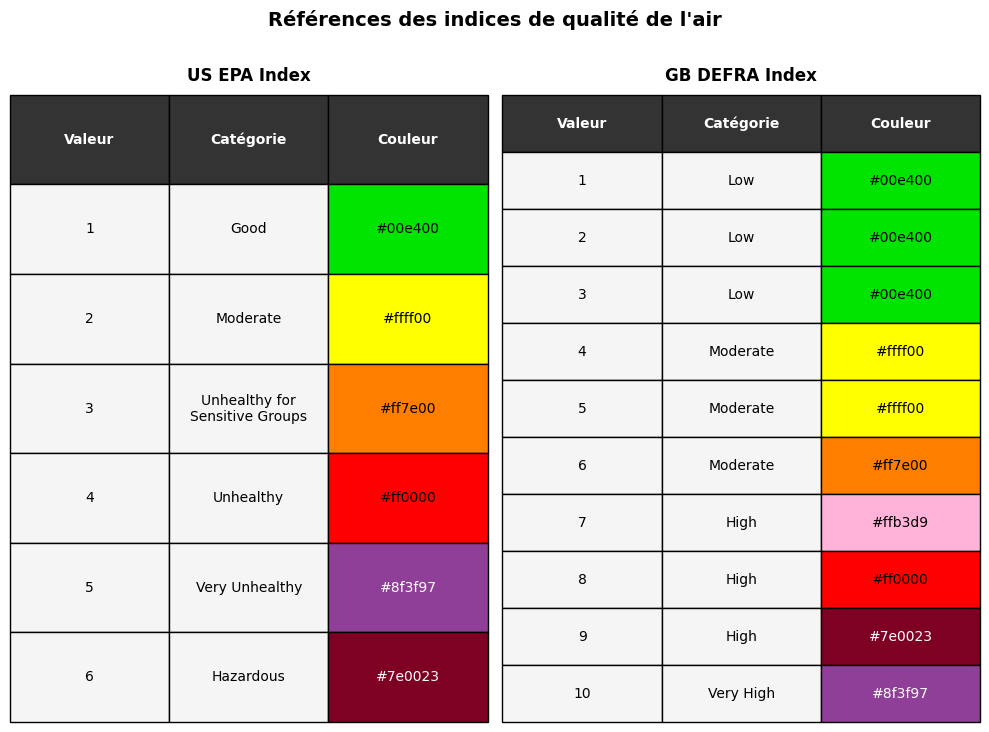

Image sauvegardée : references_indices_qualite_air.png


In [7]:
import matplotlib.pyplot as plt
import textwrap

fig, axes = plt.subplots(1, 2, figsize=(10, max(len(us_df), len(gb_df)) * 0.6 + 1.2))
fig.suptitle("Références des indices de qualité de l'air", fontsize=14, fontweight="bold", y=1.01)

def draw_table(ax, df, title, dark_colors=None):
    dark_colors = dark_colors or []
    ax.set_title(title, fontsize=12, fontweight="bold", pad=10)
    ax.axis("off")
    col_labels = ["Valeur", "Catégorie", "Couleur"]
    cell_colors = []
    for _, row in df.iterrows():
        cell_colors.append(["#f5f5f5", "#f5f5f5", row["color"]])
    table = ax.table(
        cellText=[[str(row["value"]), textwrap.fill(row["label"], 18), row["color"]] for _, row in df.iterrows()],
        colLabels=col_labels,
        cellColours=cell_colors,
        bbox=[0, 0, 1, 1],
        cellLoc="center"
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    # Header style
    for col in range(3):
        table[0, col].set_facecolor("#333333")
        table[0, col].set_text_props(color="white", fontweight="bold")
    # Color cell text
    for row_idx, (_, row) in enumerate(df.iterrows(), start=1):
        text_color = "white" if row["color"] in dark_colors else "black"
        table[row_idx, 2].set_text_props(color=text_color)

draw_table(axes[0], us_df, "US EPA Index", dark_colors=["#8f3f97", "#7e0023"])
draw_table(axes[1], gb_df, "GB DEFRA Index", dark_colors=["#7e0023", "#8f3f97"])

plt.tight_layout()
plt.savefig("references_indices_qualite_air.png", dpi=150, bbox_inches="tight")
plt.show()
print("Image sauvegardée : references_indices_qualite_air.png")


### 4. Visualisation

*L'objectif de cette partie est d'explorer le jeu de données avant nettoyage pour en dégager les premières tendances. À travers ces graphiques, nous allons identifier les valeurs atypiques, vérifier la cohérence des variables et exposer l'état initial du dataset pour mieux orienter nos futures étapes de préparation.*

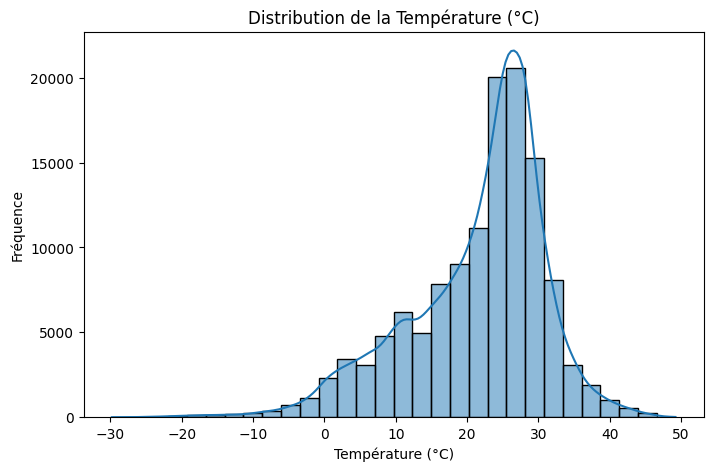

In [11]:
# 1. Distribution de la température

plt.figure(figsize=(8,5))
sns.histplot(df['temperature_celsius'].dropna(), kde=True, bins=30)
plt.title('Distribution de la Température (°C)')
plt.xlabel('Température (°C)')
plt.ylabel('Fréquence')
plt.show()


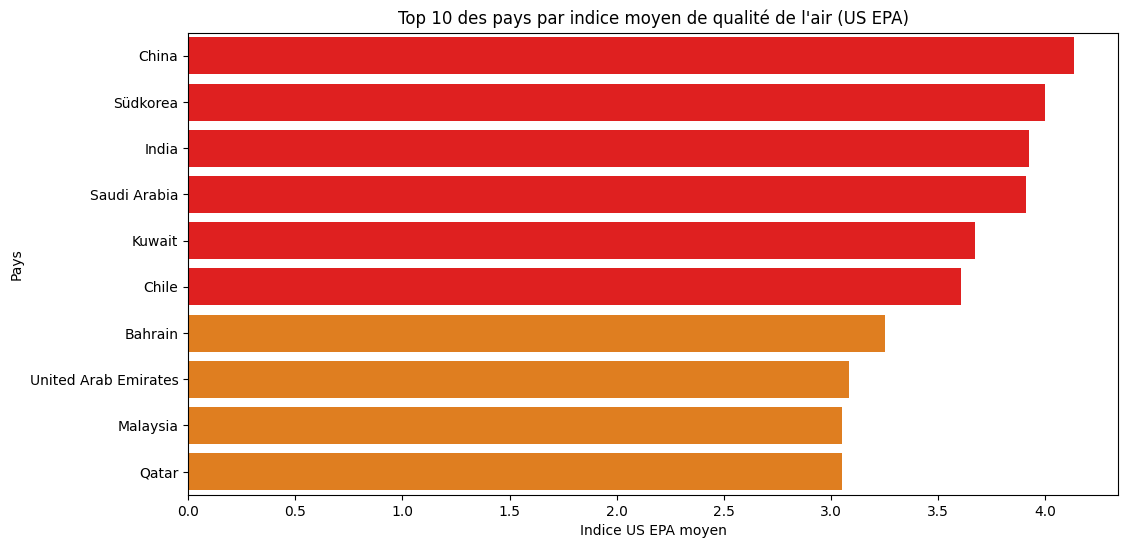

In [12]:
# 2. Diagramme en barres de l'indice de pollution moyen par pays (Top 10)

pollution_by_country = (
    df.dropna(subset=['country', 'air_quality_us-epa-index'])
      .groupby('country')['air_quality_us-epa-index']
      .mean()
      .sort_values(ascending=False)
      .head(10)
)


bar_colors = [us_colors_list[int(round(val))-1] if 1 <= int(round(val)) <= len(us_colors_list) else '#999999' for val in pollution_by_country.values]

plt.figure(figsize=(12,6))

sns.barplot(
    x=pollution_by_country.values, 
    y=pollution_by_country.index, 
    hue=pollution_by_country.index, 
    palette=bar_colors,             
    legend=False                   
)

plt.title('Top 10 des pays par indice moyen de qualité de l\'air (US EPA)')
plt.xlabel('Indice US EPA moyen')
plt.ylabel('Pays')
plt.show()

Text(0, 0.5, 'Nombre')

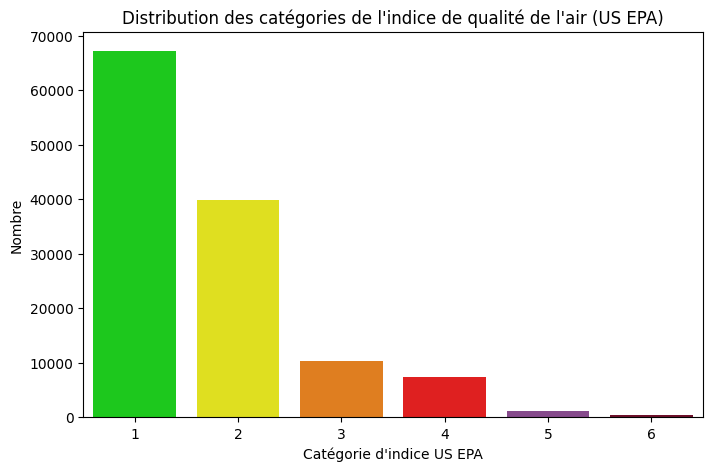

In [13]:
# 3. Distribution des catégories de qualité de l'air (US EPA index)

plt.figure(figsize=(8,5))

sns.countplot(
    data=df, 
    x='air_quality_us-epa-index', 
    hue='air_quality_us-epa-index', 
    palette=us_colors_list, 
    legend=False                   
)

plt.title('Distribution des catégories de l\'indice de qualité de l\'air (US EPA)')
plt.xlabel('Catégorie d\'indice US EPA')
plt.ylabel('Nombre')

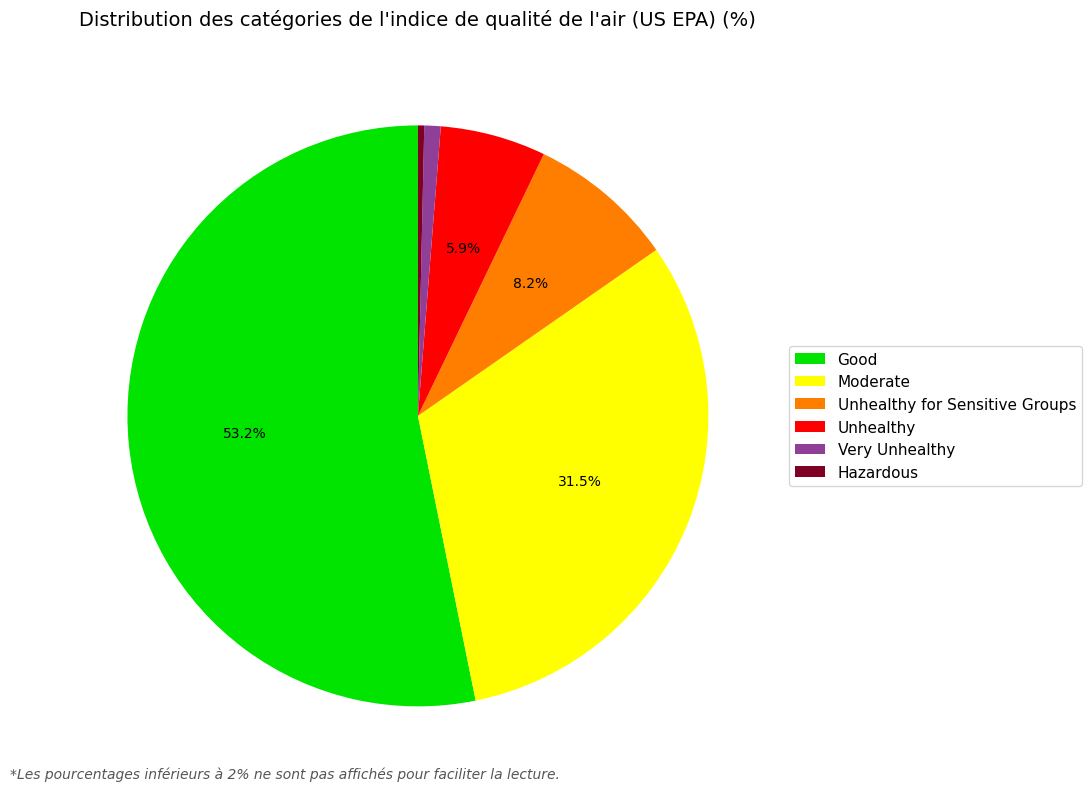

In [15]:
# 4. Pie chart de la répartition de l'indice de qualité de l'air US EPA

epa_counts = df['air_quality_us-epa-index'].value_counts().sort_index()

def autopct_format(pct):
    return f'{pct:.1f}%' if pct >= 2 else ''

plt.figure(figsize=(12,8))
plt.pie(
    epa_counts.values,
    autopct=autopct_format,
    colors=us_colors_list,
    startangle=90
)
plt.title('Distribution des catégories de l\'indice de qualité de l\'air (US EPA) (%)', fontsize=14, pad=20)
plt.legend(
    [us_map.get(int(i), f'Category {i}') for i in epa_counts.index], 
    loc='center left',
    bbox_to_anchor=(1, 0, 0.5, 1),
    fontsize=11
)

plt.figtext(0.1, 0.02, "*Les pourcentages inférieurs à 2% ne sont pas affichés pour faciliter la lecture.", 
            ha="left", fontsize=10, style='italic', color='#555555')

plt.tight_layout()
plt.show()

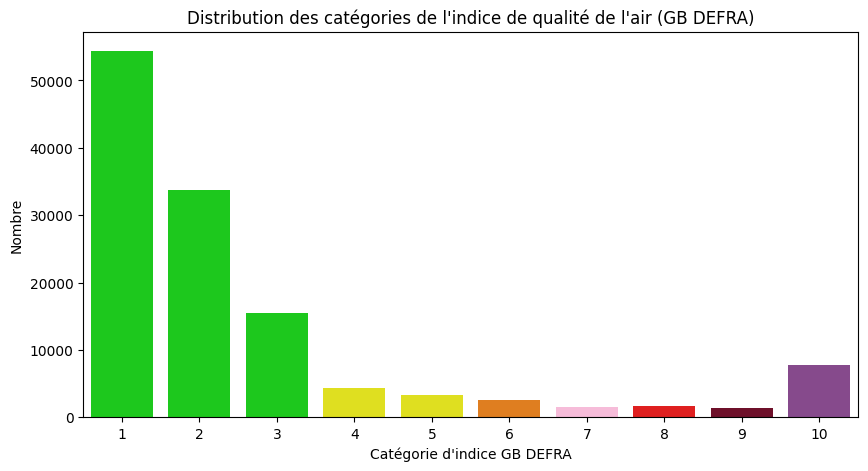

In [16]:
# 3b. Distribution des catégories de qualité de l'air (Indice GB DEFRA)

plt.figure(figsize=(10,5))

sns.countplot(
    data=df, 
    x='air_quality_gb-defra-index', 
    hue='air_quality_gb-defra-index',
    palette=defra_colors_list, 
    legend=False
)

plt.title('Distribution des catégories de l\'indice de qualité de l\'air (GB DEFRA)')
plt.xlabel('Catégorie d\'indice GB DEFRA')
plt.ylabel('Nombre')
plt.show()

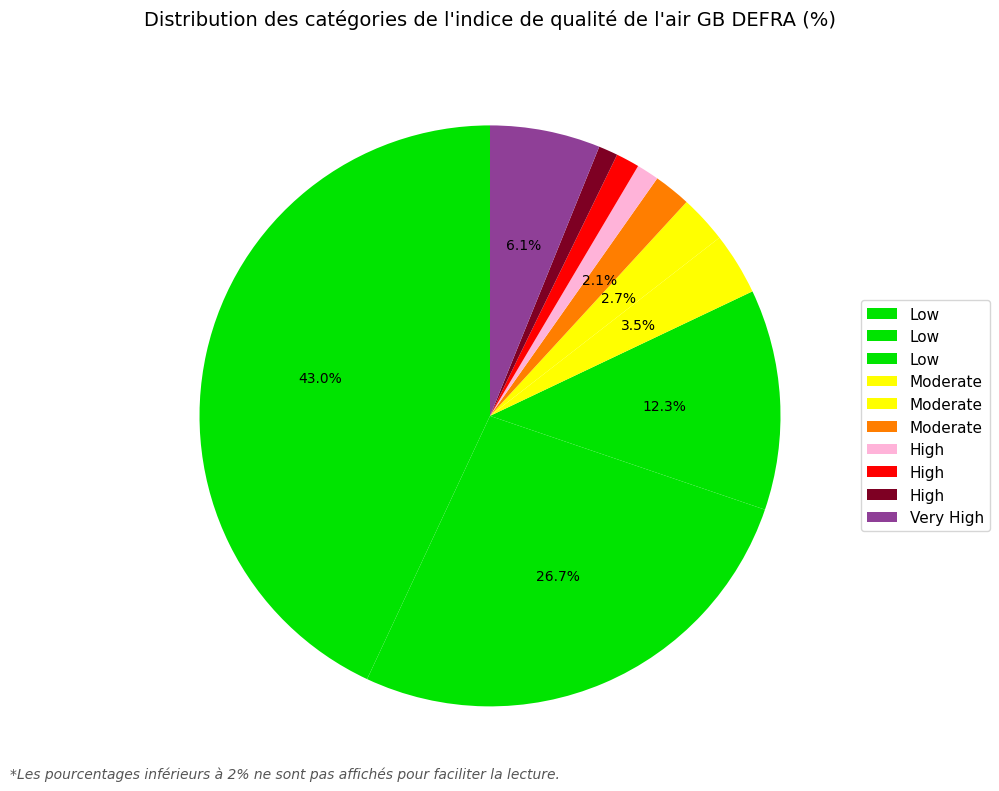

In [17]:
# 4b. Pie chart de la répartition de l'indice de qualité de l'air GB DEFRA

gb_counts = df['air_quality_gb-defra-index'].value_counts().sort_index()

def autopct_format(pct):
    return f'{pct:.1f}%' if pct >= 2 else ''

plt.figure(figsize=(12,8))
plt.pie(
    gb_counts.values,
    autopct=autopct_format,
    colors=[defra_colors_list[int(i)-1] for i in gb_counts.index],
    startangle=90
)

plt.title('Distribution des catégories de l\'indice de qualité de l\'air GB DEFRA (%)', fontsize=14, pad=20)

plt.legend(
    [gb_map.get(int(i), f'Level {i}') for i in gb_counts.index], 
    loc='center left',
    bbox_to_anchor=(1, 0, 0.5, 1),
    fontsize=11
)

plt.figtext(0.1, 0.02, "*Les pourcentages inférieurs à 2% ne sont pas affichés pour faciliter la lecture.", 
            ha="left", fontsize=10, style='italic', color='#555555')

plt.tight_layout()
plt.show()

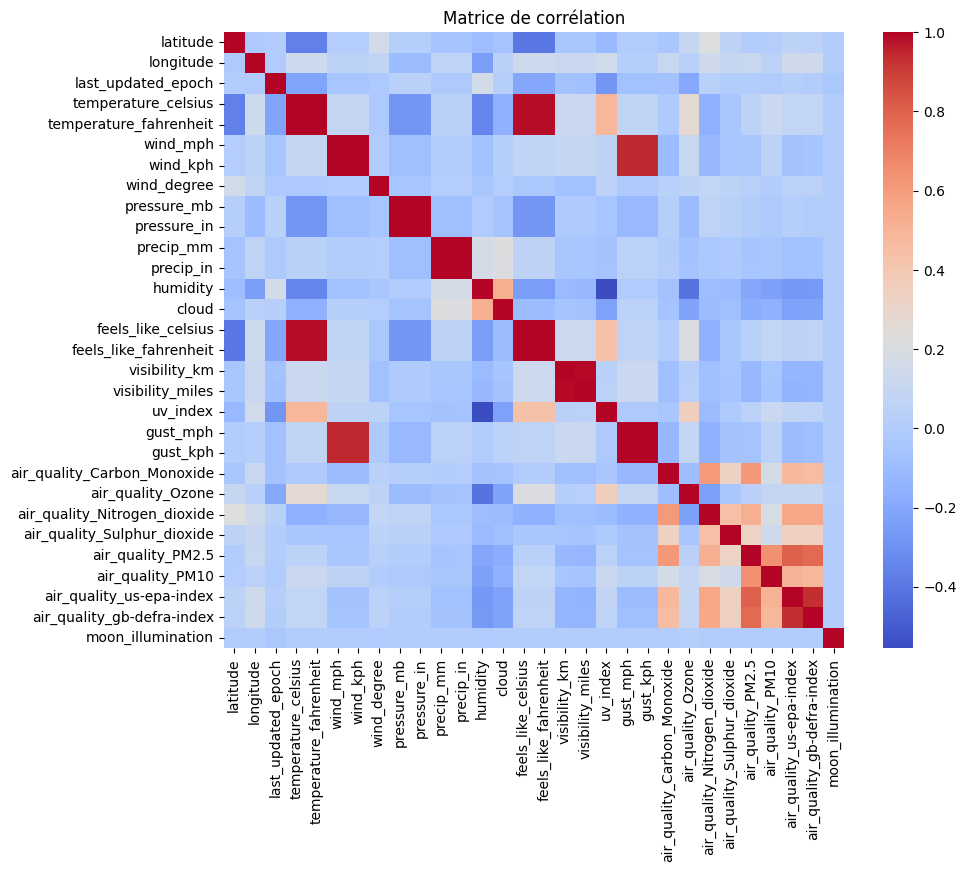

In [19]:
# 5. Matrice de corrélation des variables numériques

plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), cmap="coolwarm")
plt.title('Matrice de corrélation')
plt.show()

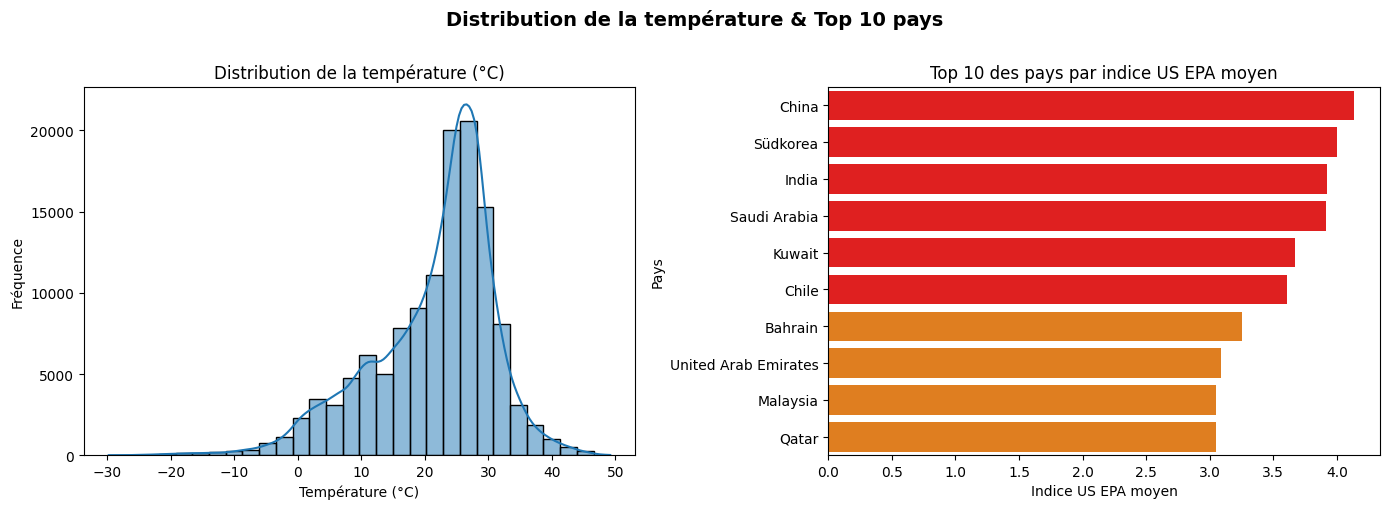

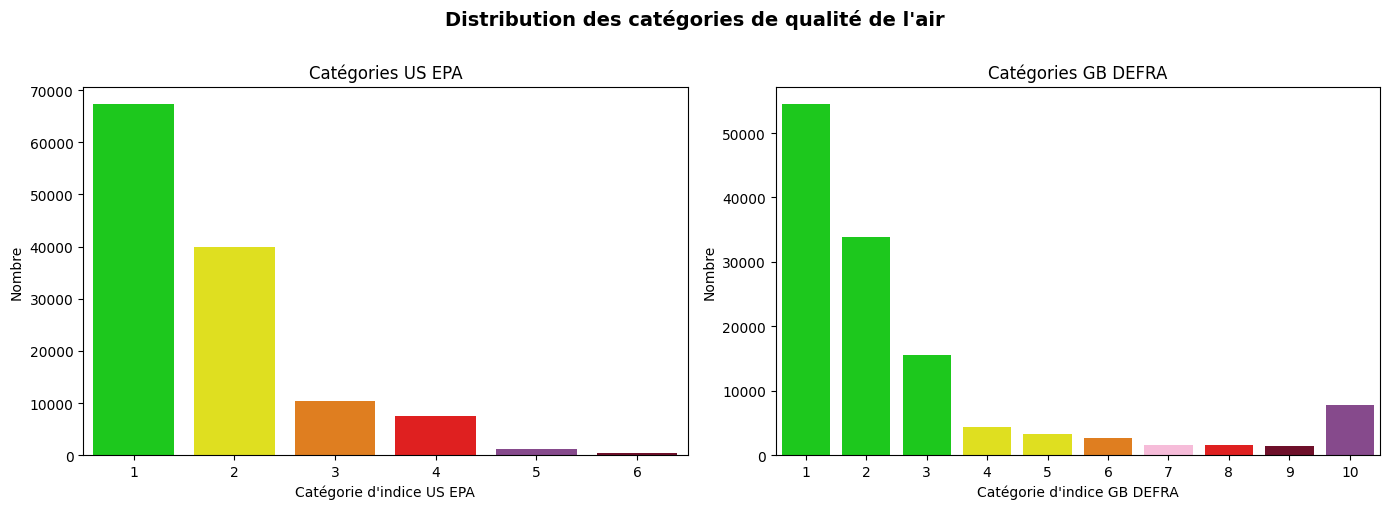

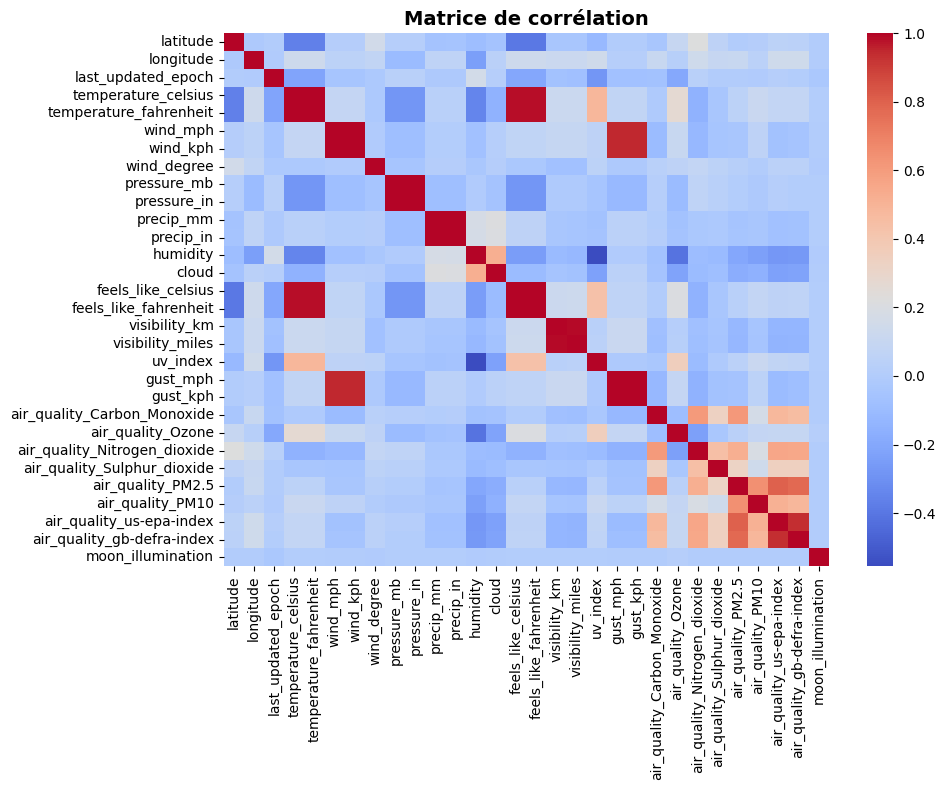

Images sauvegardées : section4_img1.png, section4_img2.png, section4_img3.png, section4_img4.png


In [21]:
import matplotlib.gridspec as gridspec                                                                                                                                       
  
# ── IMAGE 1 : Température + Top 10 Countries ──
fig1, axes1 = plt.subplots(1, 2, figsize=(14, 5))
fig1.suptitle("Distribution de la température & Top 10 pays", fontsize=14, fontweight='bold', y=1.01)

sns.histplot(df['temperature_celsius'].dropna(), kde=True, bins=30, ax=axes1[0])
axes1[0].set_title('Distribution de la température (°C)')
axes1[0].set_xlabel('Température (°C)')
axes1[0].set_ylabel('Fréquence')

pollution_by_country_tmp = (
df.dropna(subset=['country', 'air_quality_us-epa-index'])
.groupby('country')['air_quality_us-epa-index']
.mean()
.sort_values(ascending=False)
.head(10)
)
bar_colors_tmp = [us_colors_list[int(round(val))-1] if 1 <= int(round(val)) <= len(us_colors_list) else '#999999' for val in pollution_by_country_tmp.values]
sns.barplot(x=pollution_by_country_tmp.values, y=pollution_by_country_tmp.index, hue=pollution_by_country_tmp.index, palette=bar_colors_tmp, legend=False, ax=axes1[1])
axes1[1].set_title('Top 10 des pays par indice US EPA moyen')
axes1[1].set_xlabel('Indice US EPA moyen')
axes1[1].set_ylabel('Pays')

plt.tight_layout()
plt.savefig("section4_img1.png", dpi=150, bbox_inches="tight")
plt.show()

# ── IMAGE 2 : Countplot US EPA + Countplot GB DEFRA ──
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))
fig2.suptitle("Distribution des catégories de qualité de l'air", fontsize=14, fontweight='bold', y=1.01)

sns.countplot(data=df, x='air_quality_us-epa-index', hue='air_quality_us-epa-index', palette=us_colors_list, legend=False, ax=axes2[0])
axes2[0].set_title('Catégories US EPA')
axes2[0].set_xlabel("Catégorie d'indice US EPA")
axes2[0].set_ylabel('Nombre')

sns.countplot(data=df, x='air_quality_gb-defra-index', hue='air_quality_gb-defra-index', palette=defra_colors_list, legend=False, ax=axes2[1])
axes2[1].set_title('Catégories GB DEFRA')
axes2[1].set_xlabel("Catégorie d'indice GB DEFRA")
axes2[1].set_ylabel('Nombre')

plt.tight_layout()
plt.savefig("section4_img2.png", dpi=150, bbox_inches="tight")
plt.show()


# ── IMAGE 3 : Matrice de corrélation (seule) ──
fig4, ax4 = plt.subplots(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), cmap="coolwarm", ax=ax4)
ax4.set_title("Matrice de corrélation", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig("section4_img4.png", dpi=150, bbox_inches="tight")
plt.show()

print("Images sauvegardées : section4_img1.png, section4_img2.png, section4_img3.png, section4_img4.png")


## Pré-traitement des données

### 1. Traitement des données

*L'objectif de cette section est de transformer le jeu de données brut en un ensemble exploitable pour l'analyse et la modélisation. Nous allons procéder au renommage et à la suppression de certaines colonnes, ajuster les types de données et traiter les valeurs manquantes afin de garantir la fiabilité et la qualité du dataset avant son utilisation.*

In [77]:
df.columns

Index(['country', 'location_name', 'latitude', 'longitude', 'timezone',
       'last_updated_epoch', 'last_updated', 'temperature_celsius',
       'temperature_fahrenheit', 'condition_text', 'wind_mph', 'wind_kph',
       'wind_degree', 'wind_direction', 'pressure_mb', 'pressure_in',
       'precip_mm', 'precip_in', 'humidity', 'cloud', 'feels_like_celsius',
       'feels_like_fahrenheit', 'visibility_km', 'visibility_miles',
       'uv_index', 'gust_mph', 'gust_kph', 'air_quality_Carbon_Monoxide',
       'air_quality_Ozone', 'air_quality_Nitrogen_dioxide',
       'air_quality_Sulphur_dioxide', 'air_quality_PM2.5', 'air_quality_PM10',
       'air_quality_us-epa-index', 'air_quality_gb-defra-index', 'sunrise',
       'sunset', 'moonrise', 'moonset', 'moon_phase', 'moon_illumination'],
      dtype='object')

Nous procédons ici à l'élimination des colonnes jugées non nécessaires pour notre futur modèle de prédiction, afin de simplifier le jeu de données et de se concentrer uniquement sur les variables explicatives les plus pertinentes.

In [22]:
cols_to_drop = ['latitude', 'longitude','last_updated_epoch', 'condition_text', 'temperature_fahrenheit', 'wind_mph', 'pressure_in', 
               'precip_in', 'visibility_miles', 'gust_mph', 'moon_phase', 'moon_illumination', 'sunrise', 'sunset', 'moonrise', 'moonset',
               'feels_like_fahrenheit']
df_2 = df.drop(columns=cols_to_drop)

In [23]:
df_2.columns

Index(['country', 'location_name', 'timezone', 'last_updated',
       'temperature_celsius', 'wind_kph', 'wind_degree', 'wind_direction',
       'pressure_mb', 'precip_mm', 'humidity', 'cloud', 'feels_like_celsius',
       'visibility_km', 'uv_index', 'gust_kph', 'air_quality_Carbon_Monoxide',
       'air_quality_Ozone', 'air_quality_Nitrogen_dioxide',
       'air_quality_Sulphur_dioxide', 'air_quality_PM2.5', 'air_quality_PM10',
       'air_quality_us-epa-index', 'air_quality_gb-defra-index'],
      dtype='object')

Nous portons notre choix sur `l'indice air_quality_us-epa-index` comme variable de référence pour la suite de notre étude.

In [24]:
df_2 = df_2.drop(columns=['air_quality_gb-defra-index'])

In [25]:
# afficher toutes les lignes et colonnes

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)  
pd.set_option('display.max_colwidth', None) 

In [26]:
df_2.head()

,country,location_name,timezone,last_updated,temperature_celsius,wind_kph,wind_degree,wind_direction,pressure_mb,precip_mm,humidity,cloud,feels_like_celsius,visibility_km,uv_index,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index
0,Afghanistan,Kabul,Asia/Kabul,2024-05-16 13:15,26.6,13.3,338,NNW,1012.0,0.0,24,30,25.3,10.0,7.0,15.3,277.0,103.0,1.1,0.2,8.4,26.6,1
1,Albania,Tirana,Europe/Tirane,2024-05-16 10:45,19.0,11.2,320,NW,1012.0,0.1,94,75,19.0,10.0,5.0,18.4,193.6,97.3,0.9,0.1,1.1,2.0,1
2,Algeria,Algiers,Africa/Algiers,2024-05-16 09:45,23.0,15.1,280,W,1011.0,0.0,29,0,24.6,10.0,5.0,22.3,540.7,12.2,65.1,13.4,10.4,18.4,1
3,Andorra,Andorra La Vella,Europe/Andorra,2024-05-16 10:45,6.3,11.9,215,SW,1007.0,0.3,61,100,3.8,2.0,2.0,13.7,170.2,64.4,1.6,0.2,0.7,0.9,1
4,Angola,Luanda,Africa/Luanda,2024-05-16 09:45,26.0,13.0,150,SSE,1011.0,0.0,89,50,28.7,10.0,8.0,20.2,2964.0,19.0,72.7,31.5,183.4,262.3,5


In [27]:
# Exploration de la colonne timezone

df['timezone'].head(20)

0                         Asia/Kabul
1                      Europe/Tirane
2                     Africa/Algiers
3                     Europe/Andorra
4                      Africa/Luanda
5                    America/Antigua
6     America/Argentina/Buenos_Aires
7                       Asia/Yerevan
8                   Australia/Sydney
9                      Europe/Vienna
10                         Asia/Baku
11                    America/Nassau
12                      Asia/Bahrain
13                        Asia/Dhaka
14                  America/Barbados
15                      Europe/Minsk
16                   Europe/Brussels
17                    America/Belize
18                 Africa/Porto-Novo
19                      Asia/Thimphu
Name: timezone, dtype: object

Nous modifions la variable `timezone` pour ne conserver que l'information liée au continent. La précision de la ville étant déjà présente dans la colonne `location_name`, cette transformation permet d'éliminer une redondance d'information tout en créant une variable catégorielle plus large et plus utile.

In [28]:
# ne garder que le continent dans timezone (avant le "/")

df_2['timezone'] = df_2['timezone'].astype(str).str.split('/').str[0]
# éliminer les éventuels espaces
df_2['timezone'] = df_2['timezone'].str.strip()

df_2.head()

,country,location_name,timezone,last_updated,temperature_celsius,wind_kph,wind_degree,wind_direction,pressure_mb,precip_mm,humidity,cloud,feels_like_celsius,visibility_km,uv_index,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index
0,Afghanistan,Kabul,Asia,2024-05-16 13:15,26.6,13.3,338,NNW,1012.0,0.0,24,30,25.3,10.0,7.0,15.3,277.0,103.0,1.1,0.2,8.4,26.6,1
1,Albania,Tirana,Europe,2024-05-16 10:45,19.0,11.2,320,NW,1012.0,0.1,94,75,19.0,10.0,5.0,18.4,193.6,97.3,0.9,0.1,1.1,2.0,1
2,Algeria,Algiers,Africa,2024-05-16 09:45,23.0,15.1,280,W,1011.0,0.0,29,0,24.6,10.0,5.0,22.3,540.7,12.2,65.1,13.4,10.4,18.4,1
3,Andorra,Andorra La Vella,Europe,2024-05-16 10:45,6.3,11.9,215,SW,1007.0,0.3,61,100,3.8,2.0,2.0,13.7,170.2,64.4,1.6,0.2,0.7,0.9,1
4,Angola,Luanda,Africa,2024-05-16 09:45,26.0,13.0,150,SSE,1011.0,0.0,89,50,28.7,10.0,8.0,20.2,2964.0,19.0,72.7,31.5,183.4,262.3,5


In [29]:
# les valeurs uniques de 'wind_direction'

df_2['wind_direction'].unique()

array(['NNW', 'NW', 'W', 'SW', 'SSE', 'E', 'N', 'SE', 'ESE', 'NNE', 'S',
       'WSW', 'SSW', 'ENE', 'NE', 'WNW'], dtype=object)

Nous modifions ci-dessous le type de certaines colonnes pour les faire correspondre à leur nature réelle, comme le passage des variables textuelles en category et des dates en datetime. Cette étape est essentielle pour optimiser la mémoire et garantir un traitement statistique cohérent lors de la modélisation.

In [86]:
df_2.dtypes

country                          object
location_name                    object
timezone                         object
last_updated                     object
temperature_celsius             float64
wind_kph                        float64
wind_degree                       int64
wind_direction                   object
pressure_mb                     float64
precip_mm                       float64
humidity                          int64
cloud                             int64
feels_like_celsius              float64
visibility_km                   float64
uv_index                        float64
gust_kph                        float64
air_quality_Carbon_Monoxide     float64
air_quality_Ozone               float64
air_quality_Nitrogen_dioxide    float64
air_quality_Sulphur_dioxide     float64
air_quality_PM2.5               float64
air_quality_PM10                float64
air_quality_us-epa-index          int64
dtype: object

In [31]:
df_2['air_quality_us-epa-index'] = df_2['air_quality_us-epa-index'].astype('category')
df_2['wind_direction'] = df_2['wind_direction'].astype('category')
df_2['last_updated'] = pd.to_datetime(df_2['last_updated'])
df_2['country'] = df_2['country'].astype('category')
df_2['location_name'] = df_2['location_name'].astype('category')
df_2['timezone'] = df_2['timezone'].astype('category')

In [40]:
df_2.dtypes

country                               category
location_name                         category
timezone                              category
last_updated                    datetime64[ns]
temperature_celsius                    float64
wind_kph                               float64
wind_degree                              int64
wind_direction                        category
pressure_mb                            float64
precip_mm                              float64
humidity                                 int64
cloud                                    int64
feels_like_celsius                     float64
visibility_km                          float64
uv_index                               float64
gust_kph                               float64
air_quality_Carbon_Monoxide            float64
air_quality_Ozone                      float64
air_quality_Nitrogen_dioxide           float64
air_quality_Sulphur_dioxide            float64
air_quality_PM2.5                      float64
air_quality_P

Nous renommons les variables ci-dessous afin d'attribuer des noms plus explicites et compréhensibles, reflétant précisément le contenu réel des données après nos premières transformations.

In [32]:
df_2 = df_2.rename(columns={
    'timezone': 'continent',
    'location_name': 'city',
    'last_updated': 'date'
})

In [42]:
df_2.head()

,country,city,continent,date,temperature_celsius,wind_kph,wind_degree,wind_direction,pressure_mb,precip_mm,humidity,cloud,feels_like_celsius,visibility_km,uv_index,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index
0,Afghanistan,Kabul,Asia,2024-05-16 13:15:00,26.6,13.3,338,NNW,1012.0,0.0,24,30,25.3,10.0,7.0,15.3,277.0,103.0,1.1,0.2,8.4,26.6,1
1,Albania,Tirana,Europe,2024-05-16 10:45:00,19.0,11.2,320,NW,1012.0,0.1,94,75,19.0,10.0,5.0,18.4,193.6,97.3,0.9,0.1,1.1,2.0,1
2,Algeria,Algiers,Africa,2024-05-16 09:45:00,23.0,15.1,280,W,1011.0,0.0,29,0,24.6,10.0,5.0,22.3,540.7,12.2,65.1,13.4,10.4,18.4,1
3,Andorra,Andorra La Vella,Europe,2024-05-16 10:45:00,6.3,11.9,215,SW,1007.0,0.3,61,100,3.8,2.0,2.0,13.7,170.2,64.4,1.6,0.2,0.7,0.9,1
4,Angola,Luanda,Africa,2024-05-16 09:45:00,26.0,13.0,150,SSE,1011.0,0.0,89,50,28.7,10.0,8.0,20.2,2964.0,19.0,72.7,31.5,183.4,262.3,5


Nous procédons ici à la création de nouvelles variables, notamment par l'extraction d'unités temporelles (année, mois, jour, heure) à partir de la variable `date`. Cette étape est essentielle pour enrichir notre jeu de données, car elle nous permettra d'effectuer des comparaisons temporelles plus fines et d'identifier des saisonnalités ou des cycles quotidiens dans l'évolution de la pollution.

In [33]:
df_2['year'] = df_2['date'].dt.year
df_2['month'] = df_2['date'].dt.month
df_2['day'] = df_2['date'].dt.day
df_2['hour'] = df_2['date'].dt.hour

In [34]:
cols = list(df_2.columns)

# Position de la colonne 'date'
date_index = cols.index('date')

# Colonnes à déplacer
new_cols = ['year', 'month', 'day', 'hour']

# On enlève ces colonnes de leur position actuelle
for col in new_cols:
    cols.remove(col)

# On les insère juste après 'date'
for i, col in enumerate(new_cols):
    cols.insert(date_index + 1 + i, col)

# On réordonne le dataframe
df_2 = df_2[cols]

In [35]:
df_2['month_name'] = df_2['month'].map({
    1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr',
    5:'May', 6:'Jun', 7:'Jul', 8:'Aug',
    9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'
})

df_2['month_name'] = df_2['month_name'].astype('category')

In [36]:
cols = list(df_2.columns)

# Position de 'month'
month_index = cols.index('month')

# On enlève month_name de sa position actuelle
cols.remove('month_name')

# On l'insère juste après month
cols.insert(month_index + 1, 'month_name')

# Réorganisation du dataframe
df_2 = df_2[cols]

In [37]:
df_2.head()

,country,city,continent,date,year,month,month_name,day,hour,temperature_celsius,wind_kph,wind_degree,wind_direction,pressure_mb,precip_mm,humidity,cloud,feels_like_celsius,visibility_km,uv_index,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index
0,Afghanistan,Kabul,Asia,2024-05-16 13:15:00,2024,5,May,16,13,26.6,13.3,338,NNW,1012.0,0.0,24,30,25.3,10.0,7.0,15.3,277.0,103.0,1.1,0.2,8.4,26.6,1
1,Albania,Tirana,Europe,2024-05-16 10:45:00,2024,5,May,16,10,19.0,11.2,320,NW,1012.0,0.1,94,75,19.0,10.0,5.0,18.4,193.6,97.3,0.9,0.1,1.1,2.0,1
2,Algeria,Algiers,Africa,2024-05-16 09:45:00,2024,5,May,16,9,23.0,15.1,280,W,1011.0,0.0,29,0,24.6,10.0,5.0,22.3,540.7,12.2,65.1,13.4,10.4,18.4,1
3,Andorra,Andorra La Vella,Europe,2024-05-16 10:45:00,2024,5,May,16,10,6.3,11.9,215,SW,1007.0,0.3,61,100,3.8,2.0,2.0,13.7,170.2,64.4,1.6,0.2,0.7,0.9,1
4,Angola,Luanda,Africa,2024-05-16 09:45:00,2024,5,May,16,9,26.0,13.0,150,SSE,1011.0,0.0,89,50,28.7,10.0,8.0,20.2,2964.0,19.0,72.7,31.5,183.4,262.3,5


### 2. Visualisation

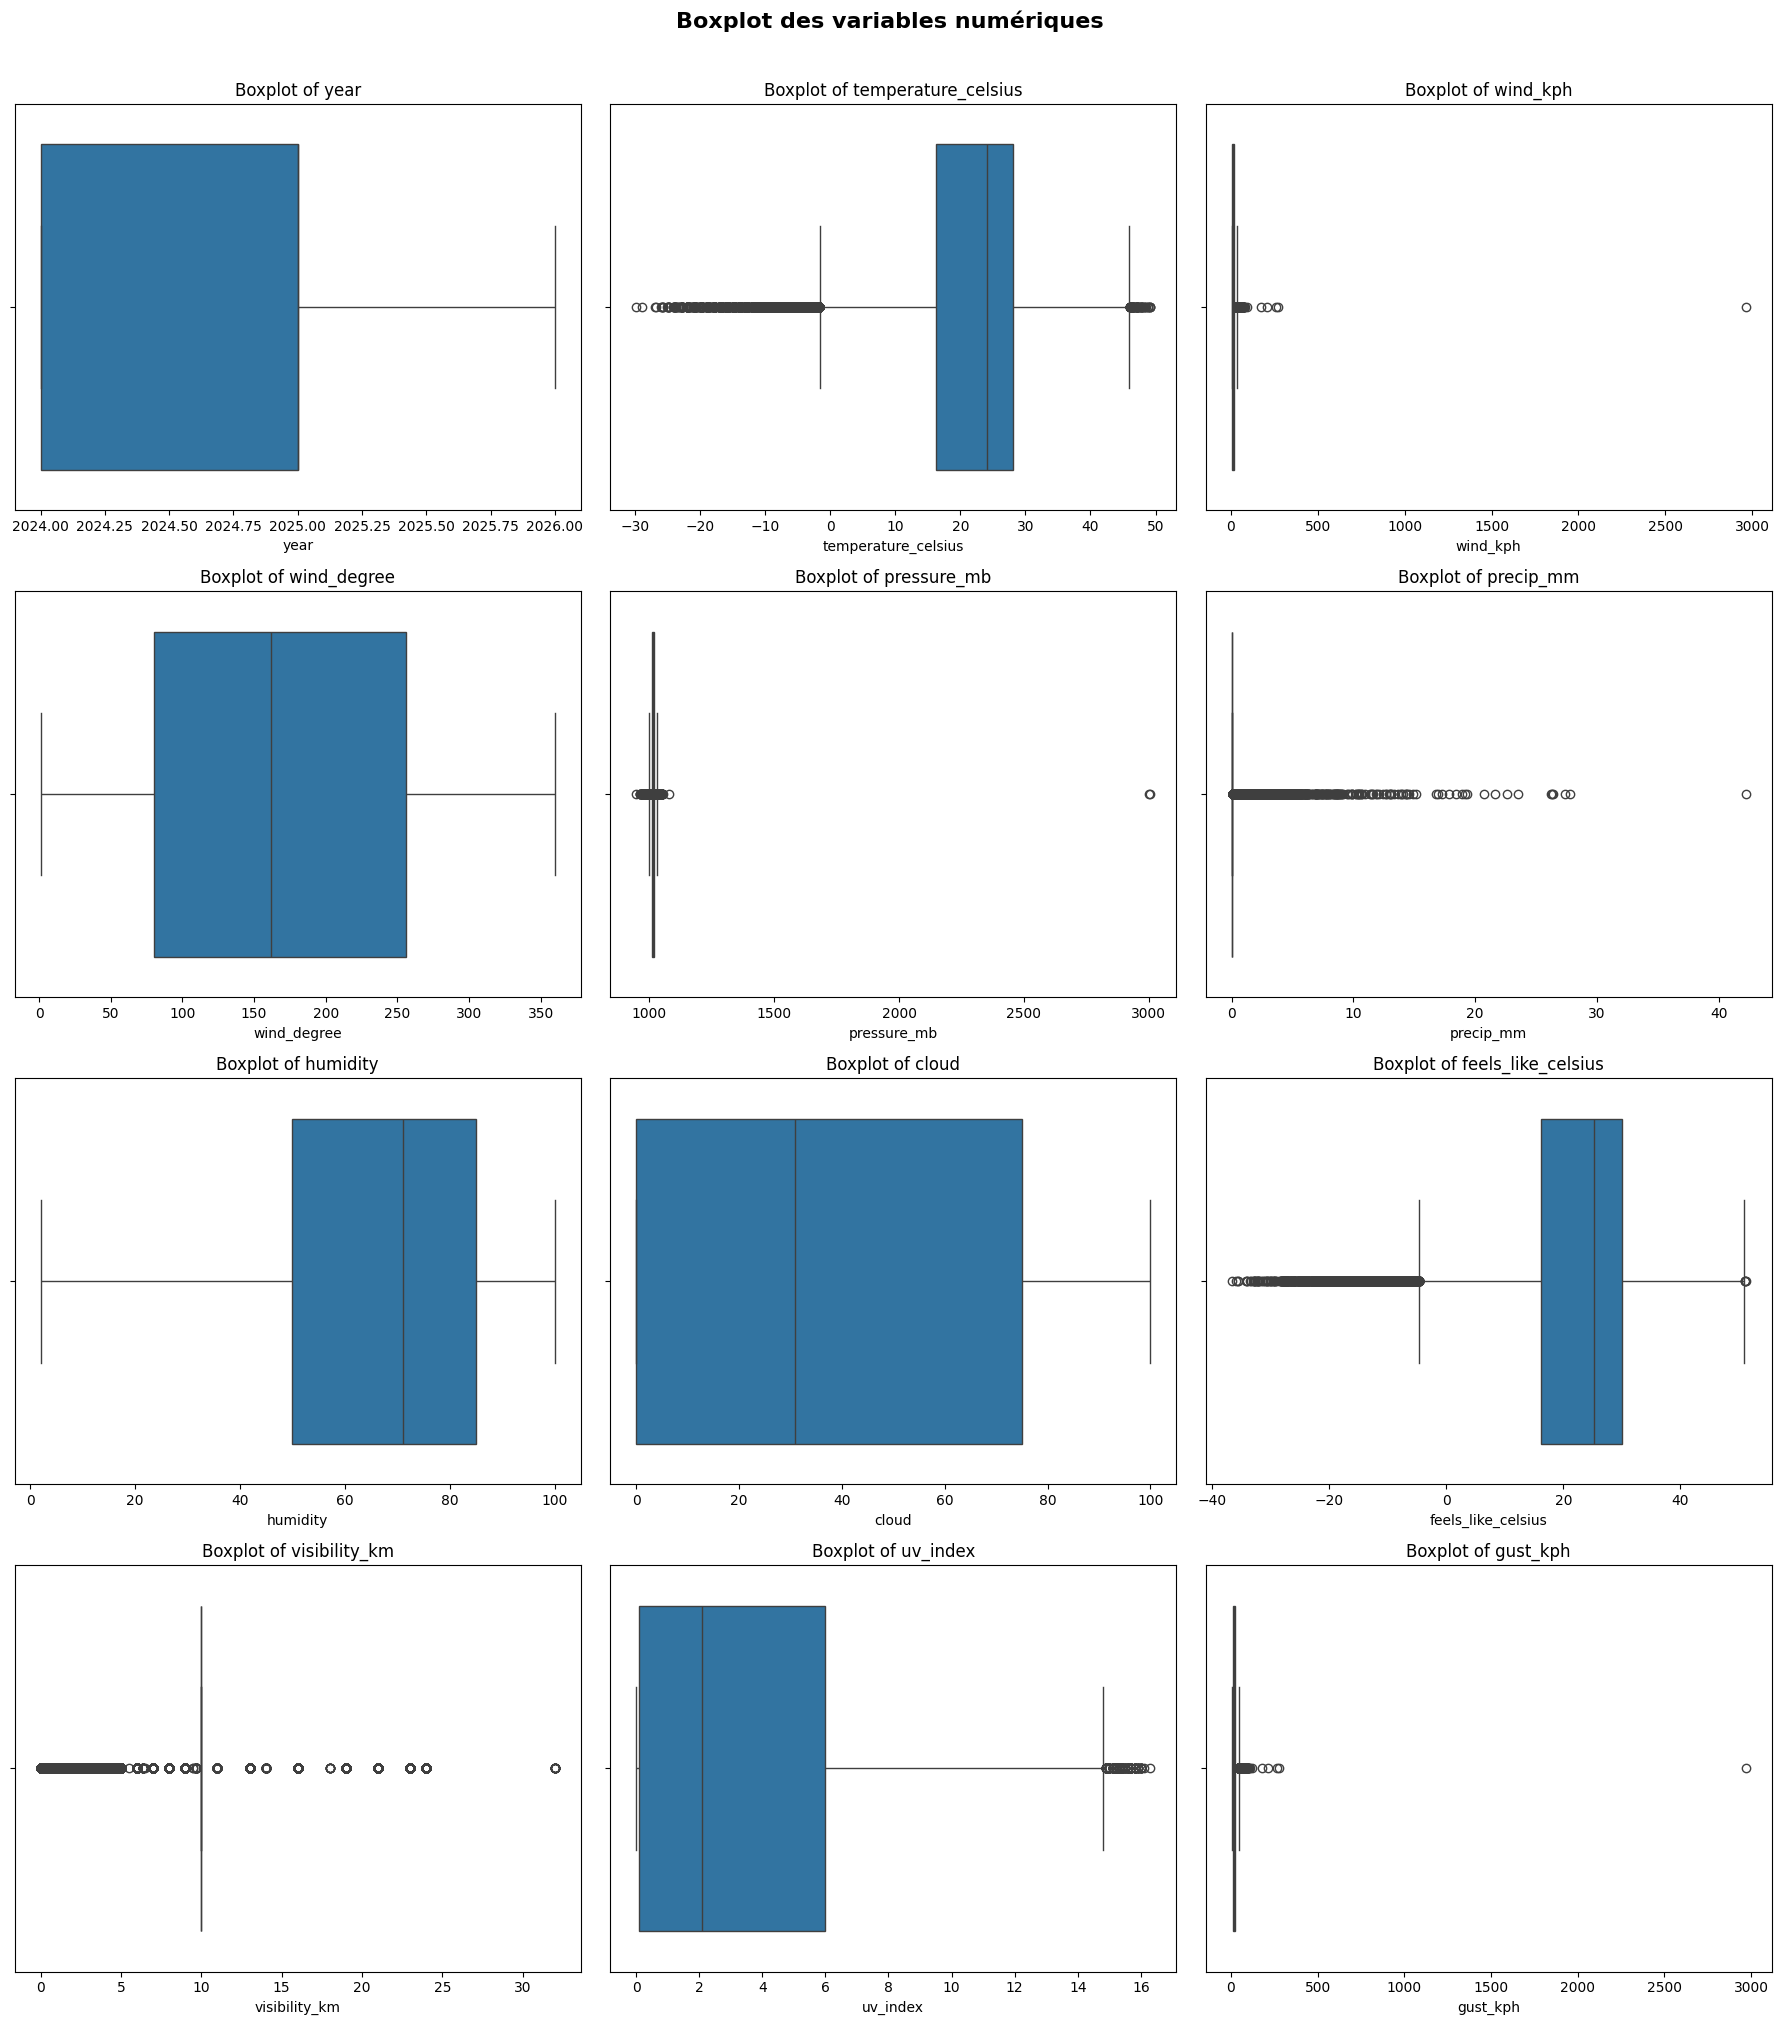

In [ ]:
# 1. Boxplots pour les variables numériques

# Sélection des colonnes numériques
num_cols = df_2.select_dtypes(include=['float64', 'int64', 'int32']).columns

# Variables à exclure
cols_to_exclude = [
    'month', 'day', 'hour',
    'air_quality_Carbon_Monoxide',
    'air_quality_Ozone',
    'air_quality_Nitrogen_dioxide',
    'air_quality_Sulphur_dioxide',
    'air_quality_PM2.5',
    'air_quality_PM10'
]


num_cols = [col for col in num_cols if col not in cols_to_exclude]


n_cols = 3
n_rows = int(np.ceil(len(num_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x=df_2[col], ax=axes[i])
    axes[i].set_title(f'Boxplot {col}')
    
# Supprimer les axes vides
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Boxplot des variables numériques', fontsize=16, fontweight='bold', y=1.01)

# enregistrer le graphique en png
plt.tight_layout()
plt.savefig("boxplots_variables_numeriques.png", dpi=150, bbox_inches="tight")
plt.show()

In [97]:
# valeur unique de 'year'
df_2['year'].unique()
#nombre de valeur par valeur unique de 'year'
df_2['year'].value_counts()

year
2025    71100
2024    44469
2026    10907
Name: count, dtype: int64

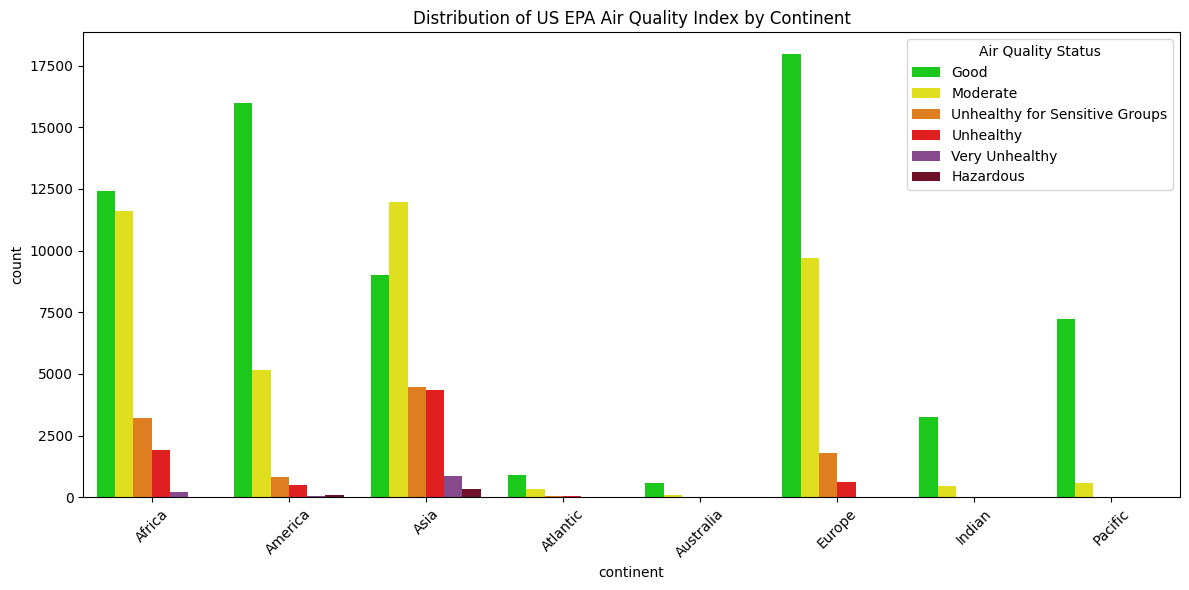

In [ ]:
# 2. Distribution de l'indice de qualité de l'air US EPA par continent

plt.figure(figsize=(12,6))

sns.countplot(
    data=df_2,
    x='continent',
    hue='air_quality_us-epa-index',
    palette=us_colors_list
)

# On récupère les noms des catégories
category_labels = [us_map.get(i, i) for i in sorted(df_2['air_quality_us-epa-index'].unique())]

plt.legend(title="Air Quality Status", labels=category_labels, loc='upper right')

plt.xticks(rotation=45)
plt.title("Distribution of US EPA Air Quality Index by Continent")


# enregistrer le graphique en png
plt.tight_layout()
plt.savefig("distribution_aqi_par_continent.png", dpi=150, bbox_inches="tight")
plt.show()

In [99]:
df_2['continent'].unique()

['Asia', 'Europe', 'Africa', 'America', 'Australia', 'Indian', 'Atlantic', 'Pacific']
Categories (8, object): ['Africa', 'America', 'Asia', 'Atlantic', 'Australia', 'Europe', 'Indian', 'Pacific']

In [100]:
df_2['continent'].value_counts()

continent
Asia         30956
Europe       30061
Africa       29403
America      22616
Pacific       7788
Indian        3703
Atlantic      1299
Australia      650
Name: count, dtype: int64

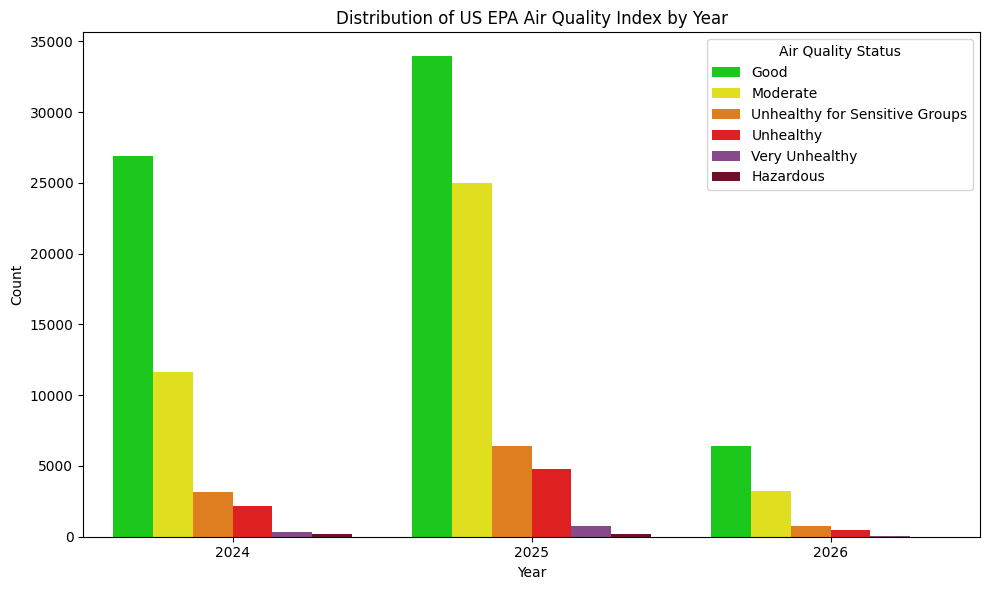

In [52]:
# 3. Distribution de l'indice de qualité de l'air US EPA par année

plt.figure(figsize=(10,6))

sns.countplot(
    data=df_2,
    x='year',
    hue='air_quality_us-epa-index',
    palette=us_colors_list
)

# On récupère les noms des catégories
category_labels = [us_map.get(i, i) for i in sorted(df_2['air_quality_us-epa-index'].unique())]

plt.title("Distribution of US EPA Air Quality Index by Year")
plt.xlabel("Year")
plt.ylabel("Count")

plt.legend(title="Air Quality Status", labels=category_labels, loc='upper right')


# enregistrer le graphique en png
plt.tight_layout()
plt.savefig("distribution_aqi_par_annee.png", dpi=150, bbox_inches="tight")
plt.show()


## Modélisation

Cette section constitue le cœur de notre étude. Notre objectif est de tester la capacité de différents algorithmes à prédire les catégories de qualité de l'air en nous appuyant sur trois scénarios distincts : l'utilisation exclusive des variables météorologiques (**Meteo Only**), l'utilisation exclusive des polluants (**Pollutants Only**), et enfin la combinaison des deux (**Meteo + Pollutants**). Cette approche nous permettra de quantifier précisément l'influence réelle de la météo sur la pollution.

La démarche se décompose comme suit :

- Division du dataset : Nous séparons nos données en un ensemble d'entraînement (train) pour permettre aux modèles d'apprendre, et un ensemble de test (test) pour évaluer leurs performances sur des données jamais vues.

- Comparaison d'algorithmes : Nous avons sélectionné trois modèles aux propriétés complémentaires :

    - **Random Forest** : Un modèle d'ensemble puissant, basé sur des arbres de décision, idéal pour capturer les relations non-linéaires.

    - **XGBoost** : Un algorithme de boosting de gradient réputé pour sa haute performance et sa capacité à traiter des relations complexes entre les variables.

    - **Régression Logistique** : Un modèle statistique plus simple qui nous servira de référence (baseline) pour évaluer le gain de performance apporté par les modèles plus complexes.

En comparant ces modèles et ces jeux de données, nous pourrons déterminer lequel est le plus apte à répondre à notre problématique et valider si les variables météorologiques suffisent à anticiper le niveau de pollution.

### 1. Split

In [102]:
target = 'air_quality_us-epa-index'

# Définir les listes de features
meteo_features = [
    'temperature_celsius',
    'wind_kph',
    'wind_degree',
    'pressure_mb',
    'precip_mm',
    'humidity',
    'cloud',
    'feels_like_celsius',
    'visibility_km',
    'uv_index',
    'gust_kph',
]

pollutant_features = [
    'air_quality_Carbon_Monoxide',
    'air_quality_Ozone',
    'air_quality_Nitrogen_dioxide',
    'air_quality_Sulphur_dioxide',
    'air_quality_PM2.5',
    'air_quality_PM10',
]

all_features = meteo_features + pollutant_features

# Split une seule fois (sur les index)
train_df, test_df = train_test_split(
    df_2,
    test_size=0.2,
    random_state=42,
    stratify=df_2[target]
)

# y
y_train = train_df[target]
y_test  = test_df[target]

# X pour les 3 modèles
X_train_meteo = train_df[meteo_features]
X_test_meteo  = test_df[meteo_features]

X_train_poll  = train_df[pollutant_features]
X_test_poll   = test_df[pollutant_features]

X_train_all   = train_df[all_features]
X_test_all    = test_df[all_features]

### 2. Modèles

In [ ]:
# 1. Random Forest

def train_and_eval_rf_metrics(model_name, X_train, y_train, X_test, y_test, params):
    y_train = y_train.astype(int)
    y_test  = y_test.astype(int)

    clf = RandomForestClassifier(**params, random_state=42)
    clf.fit(X_train, y_train)

    # prédictions
    y_pred = clf.predict(X_test)
    y_proba = clf.predict_proba(X_test)  # shape: (n_samples, n_classes)

    # Accuracy globale
    acc = accuracy_score(y_test, y_pred)

    # === Classe 1 en one-vs-rest ===
    # (binaire : 1 = classe 1, 0 = le reste)
    y_test_bin = (y_test == 1).astype(int)
    y_pred_bin = (y_pred == 1).astype(int)

    precision_1 = precision_score(y_test_bin, y_pred_bin, zero_division=0)
    recall_1    = recall_score(y_test_bin, y_pred_bin, zero_division=0)
    f1_1        = f1_score(y_test_bin, y_pred_bin, zero_division=0)

    # === ROC-AUC multiclass (OVR) ===
    # Il faut que les colonnes de proba correspondent aux labels triés
    class_labels = list(clf.classes_)  # ex: [1,2,3,4,5,6]
    roc_auc = roc_auc_score(y_test, y_proba, multi_class="ovr", labels=class_labels)

    return {
        "model": model_name,
        "accuracy": acc,
        "precision_class1": precision_1,
        "recall_class1": recall_1,
        "f1_class1": f1_1,
        "roc_auc_ovr": roc_auc
    }

# Paramètres baseline RF
rf_params = {
    "n_estimators": 300,
    "max_depth": None,
    "min_samples_split": 2,
    "min_samples_leaf": 1,
    "n_jobs": -1,
    "class_weight": "balanced"
}

# Entraîner / évaluer les 3 modèles
results = []
results.append(train_and_eval_rf_metrics("RF_Model_B_Meteo_only", X_train_meteo, y_train, X_test_meteo, y_test, rf_params))
results.append(train_and_eval_rf_metrics("RF_Model_A_Pollutants_only", X_train_poll, y_train, X_test_poll, y_test, rf_params))
results.append(train_and_eval_rf_metrics("RF_Model_C_Meteo_plus_Pollutants", X_train_all, y_train, X_test_all, y_test, rf_params))

results_df = pd.DataFrame(results)
results_df

,model,accuracy,precision_class1,recall_class1,f1_class1,roc_auc_ovr
0,RF_Model_B_Meteo_only,0.655795,0.719068,0.876468,0.790004,0.862819
1,RF_Model_A_Pollutants_only,1.000000,1.000000,1.000000,1.000000,1.000000
2,RF_Model_C_Meteo_plus_Pollutants,0.999921,1.000000,1.000000,1.000000,1.000000


In [104]:
# 2. XGBoost

def train_and_eval_xgb_metrics(model_name, X_train, y_train, X_test, y_test, params):

    # Encodage 1..6 → 0..5
    y_train_enc = y_train.astype(int) - 1
    y_test_enc  = y_test.astype(int) - 1

    num_class = int(pd.Series(y_train_enc).nunique())

    clf = xgb.XGBClassifier(
        **params,
        objective="multi:softprob",
        num_class=num_class,
        eval_metric="mlogloss",
        random_state=42,
        n_jobs=-1
    )

    clf.fit(X_train, y_train_enc)

    y_pred = clf.predict(X_test)
    y_proba = clf.predict_proba(X_test)

    # === METRICS ===
    acc = accuracy_score(y_test_enc, y_pred)

    # Classe 1 correspond à label original 1 → encodé 0
    precision_1 = precision_score(y_test_enc, y_pred, labels=[0], average='macro')
    recall_1    = recall_score(y_test_enc, y_pred, labels=[0], average='macro')
    f1_1        = f1_score(y_test_enc, y_pred, labels=[0], average='macro')

    # ROC-AUC multiclass (One-vs-Rest)
    roc_auc = roc_auc_score(y_test_enc, y_proba, multi_class="ovr")

    return {
        "model": model_name,
        "accuracy": acc,
        "precision_class1": precision_1,
        "recall_class1": recall_1,
        "f1_class1": f1_1,
        "roc_auc_ovr": roc_auc
    }


# Paramètres XGBoost
xgb_params = {
    "n_estimators": 500,
    "max_depth": 6,
    "learning_rate": 0.05,
    "subsample": 0.9,
    "colsample_bytree": 0.9,
    "reg_lambda": 1.0
}

# Entraînement des 3 modèles
results_xgb = []
results_xgb.append(train_and_eval_xgb_metrics("XGB_Meteo_only", X_train_meteo, y_train, X_test_meteo, y_test, xgb_params))
results_xgb.append(train_and_eval_xgb_metrics("XGB_Pollutants_only", X_train_poll, y_train, X_test_poll, y_test, xgb_params))
results_xgb.append(train_and_eval_xgb_metrics("XGB_Meteo_plus_Pollutants", X_train_all, y_train, X_test_all, y_test, xgb_params))

results_xgb_df = pd.DataFrame(results_xgb)
results_xgb_df

,model,accuracy,precision_class1,recall_class1,f1_class1,roc_auc_ovr
0,XGB_Meteo_only,0.638639,0.716506,0.856623,0.780324,0.857773
1,XGB_Pollutants_only,0.996917,0.999628,0.999926,0.999777,0.999913
2,XGB_Meteo_plus_Pollutants,0.997075,0.999629,1.000000,0.999814,0.999915


In [ ]:
# 3. Logistic Regression

def train_and_eval_logreg_metrics(model_name, X_train, y_train, X_test, y_test, params):

    y_train = y_train.astype(int)
    y_test  = y_test.astype(int)

    model = Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(**params, random_state=42))
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)

    # Accuracy
    acc = accuracy_score(y_test, y_pred)

    # Classe 1 vs reste
    y_test_bin = (y_test == 1).astype(int)
    y_pred_bin = (y_pred == 1).astype(int)

    precision_1 = precision_score(y_test_bin, y_pred_bin, zero_division=0)
    recall_1    = recall_score(y_test_bin, y_pred_bin, zero_division=0)
    f1_1        = f1_score(y_test_bin, y_pred_bin, zero_division=0)

    # ROC-AUC multiclass OVR
    class_labels = list(model.named_steps["clf"].classes_)
    roc_auc = roc_auc_score(y_test, y_proba, multi_class="ovr", labels=class_labels)

    return {
        "model": model_name,
        "accuracy": acc,
        "precision_class1": precision_1,
        "recall_class1": recall_1,
        "f1_class1": f1_1,
        "roc_auc_ovr": roc_auc
    }


logreg_params = {
    "max_iter": 3000,
    "C": 1.0,
    "solver": "lbfgs",
    "class_weight": "balanced"
}

results_logreg = []
results_logreg.append(train_and_eval_logreg_metrics("LogReg_Model_B_Meteo_only", X_train_meteo, y_train, X_test_meteo, y_test, logreg_params))
results_logreg.append(train_and_eval_logreg_metrics("LogReg_Model_A_Pollutants_only", X_train_poll, y_train, X_test_poll, y_test, logreg_params))
results_logreg.append(train_and_eval_logreg_metrics("LogReg_Model_C_Meteo_plus_Pollutants", X_train_all, y_train, X_test_all, y_test, logreg_params))

results_logreg_df = pd.DataFrame(results_logreg)
results_logreg_df

,model,accuracy,precision_class1,recall_class1,f1_class1,roc_auc_ovr
0,LogReg_Model_B_Meteo_only,0.394647,0.699619,0.559685,0.621877,0.686845
1,LogReg_Model_A_Pollutants_only,0.982408,0.999849,0.985580,0.992664,0.999719
2,LogReg_Model_C_Meteo_plus_Pollutants,0.981104,0.999321,0.984763,0.991989,0.999666


**Analyse des scénarios et choix du modèle final**

Dans cette étude, nous avons délibérément entraîné des modèles sur trois scénarios différents. Toutefois, il est important de préciser que les configurations incluant les polluants ont été réalisées uniquement à titre informatif et comparatif. En effet :

- L'inutilité des scénarios avec polluants : Le scénario "Polluants uniquement" affiche une Accuracy de 100% car l'indice de qualité de l'air est directement calculé à partir de ces variables ; le modèle ne fait que confirmer une règle métier préexistante. Quant au scénario "Météo + Polluants", il ne permet pas de répondre à notre problématique. Notre objectif est de déterminer si la météo seule peut prédire la pollution. Si l'on doit fournir les taux de polluants au modèle pour qu'il fonctionne, le projet perd tout son intérêt pratique et économique.

- La pertinence du scénario "Météo uniquement" : C'est le seul scénario qui constitue un véritable défi de Machine Learning et qui apporte une réponse à notre question de recherche : peut-on se passer de capteurs chimiques coûteux en utilisant des données météorologiques ?

*Le choix du gagnant : Random Forest (Meteo_only)*

En nous concentrant sur le seul scénario viable pour notre problématique, le Random Forest s'impose comme le modèle de référence.

Définition des métriques utilisées :

    - Accuracy (Exactitude) : Proportion totale de prédictions correctes sur l'ensemble des classes.

    - Precision (Classe 1 - "Good") : Capacité du modèle à ne pas classer comme "bon" un air qui serait en réalité pollué (évite les faux positifs).

    - Recall / Sensibilité (Classe 1) : Capacité du modèle à détecter le maximum d'épisodes où l'air est réellement sain (évite les faux négatifs).

    - F1-Score (Classe 1) : Équilibre entre précision et rappel, particulièrement utile ici pour juger de la performance sur la classe majoritaire "Good".

    - ROC-AUC (One-Vs-Rest) : Performance globale du modèle à distinguer chaque classe par rapport aux autres. Plus le score est proche de 1, plus le pouvoir séparateur du modèle est fort.

**Choix final** :

Le Random Forest (Meteo Only) l'emporte avec une Accuracy de 65,6% et un ROC-AUC de 0,86. Sa force réside dans son Recall élevé (0,87) pour la Classe 1, garantissant que le modèle identifie très efficacement les zones de confort respiratoire. Contrairement à la Régression Logistique, il parvient à capter les interactions physiques complexes entre les variables (comme l'effet conjugué des UV et du vent) pour en déduire un état de pollution probable.

C'est donc ce modèle que nous retenons pour notre solution finale.

### 3. Cross-validation

Afin de garantir la fiabilité de notre modèle et de s'assurer de sa capacité de généralisation, nous utilisons une Cross-Validation (K-Fold). Plutôt que de se fier à un seul découpage des données, cette méthode divise le jeu de données en $k$ parties (ici 5). Le modèle est entraîné $k$ fois, en utilisant à chaque fois une partie différente comme jeu de test et les autres comme jeu d'entraînement.

Cette approche permet de :
- Réduire le biais lié au découpage aléatoire des données.
- Vérifier la stabilité des performances (en observant l'écart-type des scores).
-Donner une estimation plus robuste de la performance réelle du modèle sur des données futures.

In [ ]:
# Cross validation

import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score


# 1. Choisir le dataset pour la CV

# CV sur tout le dataset (plus standard que CV sur train uniquement)
# -> ici: meteo only
X = df_2[meteo_features]
y = df_2["air_quality_us-epa-index"].astype(int)


# 2. Modèle RF (params identiques)

rf_params = {
    "n_estimators": 300,
    "max_depth": None,
    "min_samples_split": 2,
    "min_samples_leaf": 1,
    "n_jobs": -1,
    "class_weight": "balanced",
    "random_state": 42
}

rf = RandomForestClassifier(**rf_params)


# 3. Scorers custom (classe 1 vs reste) + ROC-AUC multiclass OVR

def precision_class1(y_true, y_pred):
    y_true_bin = (np.array(y_true) == 1).astype(int)
    y_pred_bin = (np.array(y_pred) == 1).astype(int)
    return precision_score(y_true_bin, y_pred_bin, zero_division=0)

def recall_class1(y_true, y_pred):
    y_true_bin = (np.array(y_true) == 1).astype(int)
    y_pred_bin = (np.array(y_pred) == 1).astype(int)
    return recall_score(y_true_bin, y_pred_bin, zero_division=0)

def f1_class1(y_true, y_pred):
    y_true_bin = (np.array(y_true) == 1).astype(int)
    y_pred_bin = (np.array(y_pred) == 1).astype(int)
    return f1_score(y_true_bin, y_pred_bin, zero_division=0)

def roc_auc_ovr_multiclass(y_true, y_proba):
    # y_proba: (n_samples, n_classes)
    # labels : pour être sûr de l’alignement des colonnes
    labels = np.sort(np.unique(y_true))
    return roc_auc_score(y_true, y_proba, multi_class="ovr", labels=labels)

scoring = {
    "accuracy": "accuracy",
    "precision_class1": make_scorer(precision_class1),
    "recall_class1": make_scorer(recall_class1),
    "f1_class1": make_scorer(f1_class1),
    "roc_auc_ovr": make_scorer(roc_auc_ovr_multiclass, needs_proba=True),
}


# 4. Cross-validation stratifiée

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = cross_validate(
    rf, X, y,
    scoring=scoring,
    cv=cv,
    n_jobs=-1,
    return_train_score=False
)

cv_df = pd.DataFrame(cv_results)

# Résumé mean / std
summary = cv_df.filter(like="test_").agg(["mean", "std"]).T
summary.columns = ["mean", "std"]

print("=== RandomForest 5-fold CV (stratified) ===")
print(summary.round(4))

# Détail par fold
per_fold = pd.DataFrame({
    "fold": range(1, cv_df.shape[0] + 1),
    "accuracy": cv_df["test_accuracy"],
    "precision_class1": cv_df["test_precision_class1"],
    "recall_class1": cv_df["test_recall_class1"],
    "f1_class1": cv_df["test_f1_class1"],
    "roc_auc_ovr": cv_df["test_roc_auc_ovr"],
})

print("\nScores par fold :")
print(per_fold.round(4))

=== RandomForest 5-fold CV (stratified) ===
                         mean     std
test_accuracy          0.6565  0.0011
test_precision_class1  0.7167  0.0011
test_recall_class1     0.8767  0.0047
test_f1_class1         0.7887  0.0022
test_roc_auc_ovr          NaN     NaN

Scores par fold :
   fold  accuracy  precision_class1  recall_class1  f1_class1  roc_auc_ovr
0     1    0.6563            0.7169         0.8800     0.7901          NaN
1     2    0.6551            0.7175         0.8722     0.7873          NaN
2     3    0.6579            0.7171         0.8831     0.7915          NaN
3     4    0.6570            0.7170         0.8756     0.7884          NaN
4     5    0.6563            0.7148         0.8728     0.7859          NaN


**Validation croisée du modèle Random Forest**

La validation croisée stratifiée en 5 folds montre des performances très stables du modèle Random Forest sur le scénario Meteo_only.

L’accuracy moyenne obtenue est de 0.6565 avec un écart-type très faible (± 0.0011), ce qui indique une grande stabilité des performances d’un fold à l’autre.

De même, les métriques ciblées sur la classe 1 (precision, recall et F1-score) présentent des variations très limitées entre les différents splits, confirmant la robustesse du modèle face aux différentes partitions des données.

Cette faible variance entre les folds suggère que le modèle généralise de manière cohérente et qu’il ne dépend pas fortement d’un découpage particulier du jeu de données.

### 4. Overfitting

L'overfitting survient lorsqu'un modèle apprend "par cœur" les données d'entraînement, y compris leur bruit et leurs particularités aléatoires, au lieu de saisir la logique générale. Un tel modèle affichera des performances quasi parfaites sur le jeu d'entraînement mais échouera à prédire correctement les données du jeu de test.

Pour notre modèle de Random Forest, il est essentiel de surveiller l'écart entre les scores de ces deux jeux : une précision très élevée en entraînement couplée à une chute significative sur le test confirmerait un surapprentissage, rendant le modèle inutilisable en conditions réelles.

=== AUC Train vs Test (OVR) — Meteo only ===
Micro-AUC    : Train=1.000 | Test=0.929
Macro-AUC    : Train=1.000 | Test=0.863
Weighted-AUC : Train=1.000 | Test=0.820


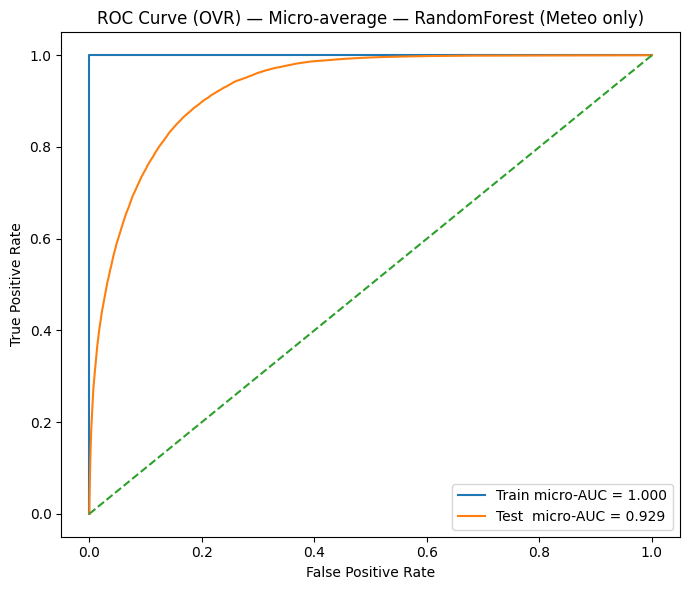

In [ ]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score

# METEO ONLY
Xtr, Xte = X_train_meteo, X_test_meteo
ytr = y_train.astype(int).values
yte = y_test.astype(int).values

rf_params = {
    "n_estimators": 300,
    "max_depth": None,
    "min_samples_split": 2,
    "min_samples_leaf": 1,
    "n_jobs": -1,
    "class_weight": "balanced",
    "random_state": 42
}

clf = RandomForestClassifier(**rf_params)
clf.fit(Xtr, ytr)

proba_tr = clf.predict_proba(Xtr)
proba_te = clf.predict_proba(Xte)

classes = np.array(clf.classes_)

# Binarisation OVR
ytr_bin = label_binarize(ytr, classes=classes)
yte_bin = label_binarize(yte, classes=classes)

# AUC micro (ROC curve)
fpr_tr, tpr_tr, _ = roc_curve(ytr_bin.ravel(), proba_tr.ravel())
fpr_te, tpr_te, _ = roc_curve(yte_bin.ravel(), proba_te.ravel())
auc_micro_tr = auc(fpr_tr, tpr_tr)
auc_micro_te = auc(fpr_te, tpr_te)

# AUC macro / weighted (plus fiable en multi-classes)
auc_macro_tr = roc_auc_score(ytr_bin, proba_tr, average="macro", multi_class="ovr")
auc_macro_te = roc_auc_score(yte_bin, proba_te, average="macro", multi_class="ovr")

auc_weighted_tr = roc_auc_score(ytr_bin, proba_tr, average="weighted", multi_class="ovr")
auc_weighted_te = roc_auc_score(yte_bin, proba_te, average="weighted", multi_class="ovr")

print("=== AUC Train vs Test (OVR) — Meteo only ===")
print(f"Micro-AUC    : Train={auc_micro_tr:.3f} | Test={auc_micro_te:.3f}")
print(f"Macro-AUC    : Train={auc_macro_tr:.3f} | Test={auc_macro_te:.3f}")
print(f"Weighted-AUC : Train={auc_weighted_tr:.3f} | Test={auc_weighted_te:.3f}")

# Plot ROC micro Train vs Test
plt.figure(figsize=(7,6))
plt.plot(fpr_tr, tpr_tr, label=f"Train micro-AUC = {auc_micro_tr:.3f}")
plt.plot(fpr_te, tpr_te, label=f"Test  micro-AUC = {auc_micro_te:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.title("ROC Curve (OVR) — Micro-average — RandomForest (Meteo only)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

**Vérification de l’overfitting**

Le modèle Random Forest atteint une performance parfaite sur l’ensemble d’entraînement (AUC = 1.000), ce qui est un comportement classique des modèles à base d’arbres non contraints, capables de mémoriser précisément les observations du jeu d’apprentissage.

Toutefois, l’évaluation sur le jeu de test montre une AUC micro de 0.929, une AUC macro de 0.863 et une AUC pondérée de 0.820.

Bien qu’un écart existe entre les performances train et test, les résultats obtenus sur les données non vues restent élevés, indiquant une bonne capacité de généralisation du modèle.

L’overfitting observé est donc modéré et n’altère pas significativement la performance prédictive du modèle.

OOB score (approx generalisation): 0.528


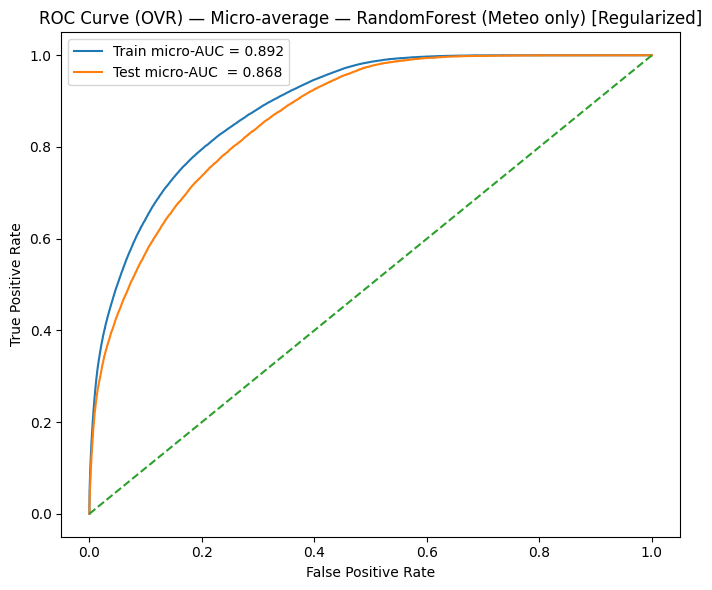

In [ ]:
# Correction overfitting

import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# METEO ONLY
Xtr, Xte = X_train_meteo, X_test_meteo
ytr = y_train.astype(int).values
yte = y_test.astype(int).values

# ✅ RandomForest "régularisé" (réduit l’overfitting)
rf_params_reg = {
    "n_estimators": 400,
    "max_depth": 11,            # limite la profondeur
    "min_samples_split": 10,    # split plus strict
    "min_samples_leaf": 4,      # feuilles plus grosses -> moins de mémorisation
    "max_features": "sqrt",     # moins de features testées à chaque split
    "bootstrap": True,
    "oob_score": True,          # optionnel: score out-of-bag
    "n_jobs": -1,
    "class_weight": "balanced",
    "random_state": 42
}

clf = RandomForestClassifier(**rf_params_reg)
clf.fit(Xtr, ytr)

print("OOB score (approx generalisation):", round(clf.oob_score_, 4))

# Probabilités
proba_tr = clf.predict_proba(Xtr)
proba_te = clf.predict_proba(Xte)

classes = np.array(clf.classes_)
ytr_bin = label_binarize(ytr, classes=classes)
yte_bin = label_binarize(yte, classes=classes)

# Micro-average ROC (OVR)
fpr_tr, tpr_tr, _ = roc_curve(ytr_bin.ravel(), proba_tr.ravel())
fpr_te, tpr_te, _ = roc_curve(yte_bin.ravel(), proba_te.ravel())

auc_tr = auc(fpr_tr, tpr_tr)
auc_te = auc(fpr_te, tpr_te)

plt.figure(figsize=(7, 6))
plt.plot(fpr_tr, tpr_tr, label=f"Train micro-AUC = {auc_tr:.3f}")
plt.plot(fpr_te, tpr_te, label=f"Test micro-AUC  = {auc_te:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve (OVR) — Micro-average — RandomForest (Meteo only) [Regularized]")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

**Réduction de l’overfitting**

Afin de limiter la capacité de mémorisation excessive du modèle Random Forest initial, plusieurs contraintes ont été introduites (limitation de la profondeur des arbres, augmentation du nombre minimum d’échantillons par feuille et par split).

Le modèle régularisé obtient :

AUC train = 0.892

AUC test = 0.868

L’écart entre train et test est désormais réduit (≈ 0.024 contre ≈ 0.071 précédemment), ce qui indique une meilleure capacité de généralisation.




**Choix final du modèle**

Deux versions du modèle Random Forest ont été évaluées : une version non contrainte présentant un certain niveau d’overfitting, et une version régularisée visant à réduire cet écart.

Bien que le modèle régularisé présente un écart train/test plus faible, il entraîne une diminution significative des performances prédictives (baisse de l’AUC et de l’accuracy sur le jeu de test).

Le modèle initial, bien que montrant une capacité de mémorisation élevée sur le jeu d’entraînement, conserve d’excellentes performances sur le jeu de test (AUC ≈ 0.92) et une stabilité satisfaisante en validation croisée.

L’overfitting observé est donc considéré comme modéré et acceptable au regard du gain substantiel en performance prédictive.

Le modèle Random Forest non contraint est ainsi retenu comme modèle final pour l’analyse météorologique.

## Interprétabilité

**Interprétation du Modèle : Importance des Variables (Gini Importance)**

Pour comprendre comment notre Random Forest prend ses décisions, nous utilisons l'importance de Gini (Mean Decrease Impurity). Cette méthode calcule à quel point chaque variable météorologique contribue à la pureté des nœuds de l'arbre lors de la classification. Plus une variable a un score élevé, plus elle est déterminante pour prédire précisément la catégorie de qualité de l'air.

Cette analyse est capitale pour notre problématique, car elle permet de passer d'un modèle "boîte noire" à un outil explicatif capable d'identifier les facteurs météorologiques (vent, UV, humidité, etc.) qui influencent le plus la pollution atmosphérique dans notre jeu de données.


In [ ]:
# 1. On ré-entraîne rapidement le modèle retenu (non contraint) pour l'avoir en mémoire

best_rf_params = {
    "n_estimators": 300,
    "max_depth": None,
    "min_samples_split": 2,
    "min_samples_leaf": 1,
    "n_jobs": -1,
    "class_weight": "balanced",
    "random_state": 42
}
final_model = RandomForestClassifier(**best_rf_params)
final_model.fit(X_train_meteo, y_train.astype(int))

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

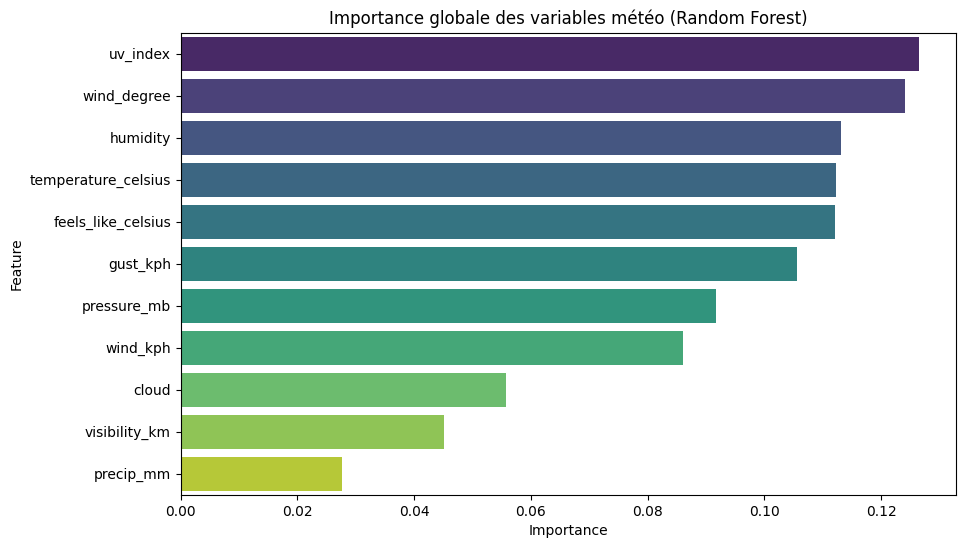

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Récupération des importances depuis le 'final_model'
importances = final_model.feature_importances_
feature_names = meteo_features

# Création d'un DataFrame pour la visualisation
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Visualisation
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=feature_importance_df, 
    palette='viridis', 
    hue='Feature', 
    legend=False   
)
plt.title('Importance globale des variables météo (Random Forest)')
plt.show()

**Analyse de l'importance des variables (Feature Importance)**

Ce graphique présente l'importance relative de chaque variable météorologique dans le processus de décision du modèle Random Forest pour prédire la catégorie de qualité de l'air (US EPA Index). L'importance est calculée selon le critère d'impureté de Gini : plus la valeur est élevée, plus la variable a été déterminante pour classer correctement les données.

*Observations principales* :

Prédominance des facteurs de rayonnement et de circulation :

    - L'indice UV (uv_index) apparaît comme la variable la plus influente (env. 12,5 %). Cela s'explique physiquement par le fait que le rayonnement solaire favorise les réactions chimiques dans l'atmosphère, notamment la formation d'ozone troposphérique (un polluant clé).

    - La direction du vent (wind_degree) suit de près. Elle est cruciale car elle détermine la provenance des masses d'air (zones industrielles vs zones naturelles) et donc le transport des polluants vers une localité donnée.

Impact des conditions thermodynamiques :

    - L'humidité (humidity) et la température (temperature_celsius / feels_like_celsius) occupent des positions centrales. Ces facteurs influencent la dispersion des particules fines et la vitesse des réactions chimiques atmosphériques.

Variables de dispersion mécanique :

    - La vitesse des rafales (gust_kph) et la pression atmosphérique (pressure_mb) montrent une importance significative. Une pression élevée (anticyclone) est souvent synonyme de stabilité de l'air et donc d'accumulation de pollution au sol.

Variables moins contributives :

    - La nébulosité (cloud), la visibilité (visibility_km) et les précipitations (precip_mm) ferment le classement. Bien que les pluies aient un effet de "lessivage" de l'air, elles semblent ici moins discriminantes que les facteurs de rayonnement et de vent pour prédire l'indice global sur l'ensemble du dataset.

## Conclusion

L'objectif de cette étude était de déterminer dans quelle mesure les variables météorologiques permettent d'anticiper la catégorie globale de qualité de l'air, en faisant abstraction des mesures directes de polluants. Au terme de cette analyse, plusieurs conclusions majeures s'imposent :

**1. Performance et fiabilité du modèle**

Pour répondre à cette problématique, nous avons privilégié un modèle de forêt aléatoire (Random Forest). Ce choix s'est avéré concluant puisque le modèle atteint une accuracy de 65,6 % sur le jeu de test. Plus significatif encore pour un problème multi-classes, l'AUC (Aire sous la courbe ROC) s'élève à 0,86, ce qui démontre une excellente capacité du modèle à distinguer les différentes catégories de qualité de l'air uniquement à partir de données météo. Bien qu'une légère tendance au surapprentissage (overfitting) ait été notée, la stabilité des scores en validation croisée confirme la robustesse de ces résultats.

**2. Les leviers météorologiques de la pollution**

Grâce aux outils d'interprétabilité (Gini Importance), nous avons identifié les facteurs clés qui "pilotent" la qualité de l'air dans notre modèle :

- Le rayonnement solaire (UV Index) : C'est la variable la plus prédictive. Cela souligne le rôle crucial de l'énergie solaire dans la formation de polluants secondaires comme l'ozone.

- La dynamique des vents (Wind Degree & Gust) : La direction et la force du vent déterminent si les polluants sont dispersés ou, au contraire, transportés depuis des zones industrielles vers les centres urbains.

- Les conditions thermodynamiques (Humidité et Pression) : Ces variables influent sur la stabilité de la masse d'air. Une pression haute et une humidité spécifique favorisent souvent la stagnation des particules fines au niveau du sol.

**3. Réponse à la problématique**

Les résultats montrent que les variables météorologiques sont des indicateurs avancés performants de la qualité de l'air. Si elles ne remplacent pas les capteurs chimiques pour une mesure précise, elles permettent d'anticiper la catégorie globale (Good, Moderate, Unhealthy, etc.) avec une fiabilité élevée.

Cette capacité d'anticipation repose sur une réalité physique : la météo ne se contente pas d'accompagner la pollution, elle en est le moteur ou le frein. Les conditions atmosphériques agissent comme un réacteur chimique géant (via les UV) et un système de distribution (via le vent et la pression).

En conclusion, cette étude démontre qu'il est tout à fait possible de construire des systèmes d'alerte précoce basés uniquement sur des prévisions météorologiques. Dans des régions où les stations de mesure de qualité de l'air sont rares ou coûteuses à entretenir, l'utilisation de modèles prédictifs basés sur la météo constitue une alternative crédible et efficace pour protéger la santé publique.

In [115]:
# On sauvegarde le modèle final et la liste des features
model_data = {
    "model": final_model,
    "features": meteo_features
}

joblib.dump(model_data, 'rf_meteo_model.pkl')
print("Modèle sauvegardé avec succès !")

Modèle sauvegardé avec succès !
